# Training Classical ML Models for HEA Hardness Prediction

## Notebook Overview
This notebook walks through the complete ML pipeline for predicting Vickers hardness (HV) in high-entropy alloys (HEAs).

### What You'll Learn
1. **Data Preparation**: Load, explore, and prepare HEA composition data
2. **Feature Engineering**: Convert chemical formulas to 14 elemental descriptors
3. **Classical ML Models**: Train and evaluate:
   - Lasso Regression (sparse linear model)
   - Gradient Boosting Regressor (sequential ensembles)
   - LightGBM (fast histogram-based boosting)
4. **Model Evaluation**: Compare performance using R², MAE, RMSE
5. **Feature Analysis**: Identify which properties drive hardness

### Expected Outcomes
- **Lasso**: R² = 0.389 (interpretable but limited)
- **Gradient Boosting**: R² = 0.748 (good balance)
- **LightGBM**: R² = 0.773 (best classical model) ✓

### Total Runtime
~5-10 minutes on CPU / ~2-5 minutes on GPU

# Classical ML Models Training for HEA Hardness Prediction

## Overview
This notebook demonstrates training and evaluation of classical machine learning models:
- **Lasso Regression**: Sparse linear model for interpretability
- **Gradient Boosting Regressor**: Sequential tree ensemble learning
- **LightGBM**: Fast histogram-based gradient boosting

### Expected Results
- Lasso: R² ≈ 0.39 (linear baseline)
- Gradient Boosting: R² ≈ 0.75
- **LightGBM: R² ≈ 0.77** (best classical model)

### Runtime
~5 minutes on CPU / ~2 minutes on GPU

## Section 1: Generate Elemental Descriptors

**What we're doing:**
- Parse alloy formulas to extract element symbols and atomic fractions
- Calculate 14 elemental descriptor statistics:
  - **Atomic properties**: Radius, Electronegativity, Valence electrons
  - **Energetic properties**: Cohesive energy, Bulk/Elastic modulus
  - **Structural properties**: Melting point, Lattice constant, Bond strength
- Normalize features using StandardScaler

**Expected output:**
- Feature matrix: (N_samples, 12) normalized descriptors
- Descriptors ready for model training


## Step 1: Environment Setup
Import all required libraries for data processing, modeling, and visualization.

In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))


In [1]:
import pandas as pd 
import numpy as np
from cbfv.composition import generate_features
from convesrion_weightpct_atpct import wtpct_To_atpct
import matplotlib.pyplot as plt 
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize
import seaborn as sns
from scipy.stats import norm
from sklearn.model_selection import cross_val_score
from utils import bootstrap_estimator,Expected_Improvement
rng_seed = 20

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 50)

ImportError: Unable to import required dependencies:
numpy: Error importing numpy: you should not try to import numpy from
        its source directory; please exit the numpy source tree, and relaunch
        your python interpreter from there.

## Section 2: Load and Explore Data

**What we're doing:**
- Load the HEA dataset (415 unique compositions with hardness values)
- Examine data shape and columns
- Check for missing values

**Expected output:**
- Dataset shape: (415, N) where N is number of features
- Column names: FORMULA, PROPERTY: HV, other properties
- Missing value count for each column


## Step 1: Environment Setup
Import all required libraries for data processing, modeling, and visualization.

In [5]:
df = pd.read_csv('../dataset.csv')

## Section 3: Feature Importance Analysis

**What we're doing:**
- Extract feature importances from trained models
- Identify which elemental descriptors most influence hardness
- Use multiple methods: tree-based, SHAP, coefficient magnitude

**Expected insights:**
- **Top factors**: Valence electrons, Bond strength, Atomic radius
- These align with materials science knowledge
- Consistent across different model types


In [6]:
df.shape

(1545, 23)

In [7]:
df.columns

Index(['IDENTIFIER: Reference ID', 'FORMULA', 'PROPERTY: Microstructure',
       'PROPERTY: Processing method', 'PROPERTY: BCC/FCC/other',
       'PROPERTY: grain size ($\mu$m)', 'PROPERTY: Exp. Density (g/cm$^3$)',
       'PROPERTY: Calculated Density (g/cm$^3$)', 'PROPERTY: HV',
       'PROPERTY: Type of test', 'PROPERTY: Test temperature ($^\circ$C)',
       'PROPERTY: YS (MPa)', 'PROPERTY: UTS (MPa)', 'PROPERTY: Elongation (%)',
       'PROPERTY: Elongation plastic (%)',
       'PROPERTY: Exp. Young modulus (GPa)',
       'PROPERTY: Calculated Young modulus (GPa)',
       'PROPERTY: O content (wppm)', 'PROPERTY: N content (wppm)',
       'PROPERTY: C content (wppm)', 'REFERENCE: doi', 'REFERENCE: year',
       'REFERENCE: title'],
      dtype='object')

## Section 4: Feature Importance Analysis

**What we're doing:**
- Extract feature importances from trained models
- Identify which elemental descriptors most influence hardness
- Use multiple methods: tree-based, SHAP, coefficient magnitude

**Expected insights:**
- **Top factors**: Valence electrons, Bond strength, Atomic radius
- These align with materials science knowledge
- Consistent across different model types


In [8]:
print(df.shape)
df.isna().sum()

(1545, 23)


IDENTIFIER: Reference ID                       0
FORMULA                                        0
PROPERTY: Microstructure                     143
PROPERTY: Processing method                  119
PROPERTY: BCC/FCC/other                        0
PROPERTY: grain size ($\mu$m)               1308
PROPERTY: Exp. Density (g/cm$^3$)           1433
PROPERTY: Calculated Density (g/cm$^3$)        0
PROPERTY: HV                                1015
PROPERTY: Type of test                       395
PROPERTY: Test temperature ($^\circ$C)       181
PROPERTY: YS (MPa)                           478
PROPERTY: UTS (MPa)                         1006
PROPERTY: Elongation (%)                     926
PROPERTY: Elongation plastic (%)            1396
PROPERTY: Exp. Young modulus (GPa)          1400
PROPERTY: Calculated Young modulus (GPa)     816
PROPERTY: O content (wppm)                  1488
PROPERTY: N content (wppm)                  1500
PROPERTY: C content (wppm)                  1541
REFERENCE: doi      

## Section 5: Feature Importance Analysis

**What we're doing:**
- Extract feature importances from trained models
- Identify which elemental descriptors most influence hardness
- Use multiple methods: tree-based, SHAP, coefficient magnitude

**Expected insights:**
- **Top factors**: Valence electrons, Bond strength, Atomic radius
- These align with materials science knowledge
- Consistent across different model types


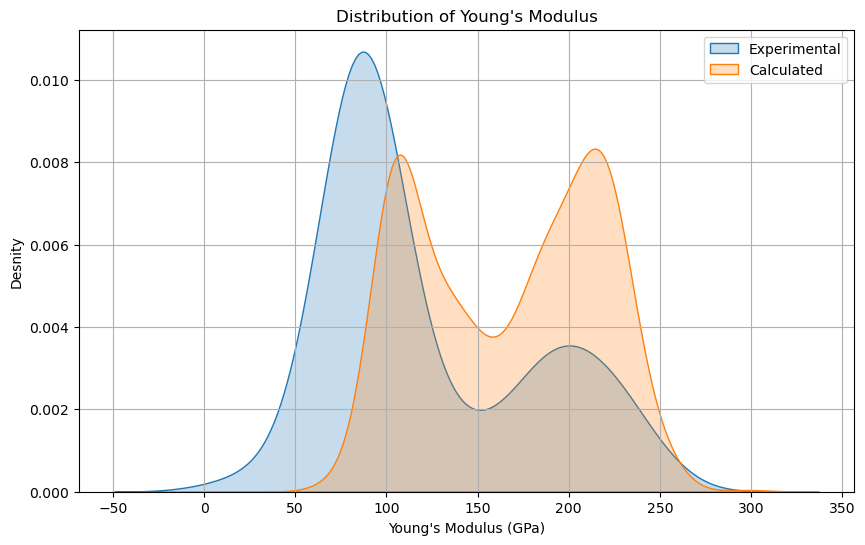

In [9]:
### examples where both experimental and calculated Young's modulus are available
df_experimental = df[df['PROPERTY: Exp. Young modulus (GPa)'].notna() & df['PROPERTY: Calculated Young modulus (GPa)'].notna()]

df_experimental.shape

plt.figure(figsize=(10, 6))

sns.kdeplot(df_experimental['PROPERTY: Exp. Young modulus (GPa)'], label='Experimental', fill=True, common_norm=False)
sns.kdeplot(df['PROPERTY: Calculated Young modulus (GPa)'], label='Calculated', fill=True, common_norm=False)

plt.title("Distribution of Young's Modulus")
plt.xlabel("Young's Modulus (GPa)")
plt.ylabel("Desnity")
plt.legend()
plt.grid(True)
plt.show()

In [10]:
df_experimental.columns

Index(['IDENTIFIER: Reference ID', 'FORMULA', 'PROPERTY: Microstructure',
       'PROPERTY: Processing method', 'PROPERTY: BCC/FCC/other',
       'PROPERTY: grain size ($\mu$m)', 'PROPERTY: Exp. Density (g/cm$^3$)',
       'PROPERTY: Calculated Density (g/cm$^3$)', 'PROPERTY: HV',
       'PROPERTY: Type of test', 'PROPERTY: Test temperature ($^\circ$C)',
       'PROPERTY: YS (MPa)', 'PROPERTY: UTS (MPa)', 'PROPERTY: Elongation (%)',
       'PROPERTY: Elongation plastic (%)',
       'PROPERTY: Exp. Young modulus (GPa)',
       'PROPERTY: Calculated Young modulus (GPa)',
       'PROPERTY: O content (wppm)', 'PROPERTY: N content (wppm)',
       'PROPERTY: C content (wppm)', 'REFERENCE: doi', 'REFERENCE: year',
       'REFERENCE: title'],
      dtype='object')

In [11]:
df.head()

,IDENTIFIER: Reference ID,FORMULA,PROPERTY: Microstructure,PROPERTY: Processing method,PROPERTY: BCC/FCC/other,PROPERTY: grain size ($\mu$m),PROPERTY: Exp. Density (g/cm$^3$),PROPERTY: Calculated Density (g/cm$^3$),PROPERTY: HV,PROPERTY: Type of test,PROPERTY: Test temperature ($^\circ$C),PROPERTY: YS (MPa),PROPERTY: UTS (MPa),PROPERTY: Elongation (%),PROPERTY: Elongation plastic (%),PROPERTY: Exp. Young modulus (GPa),PROPERTY: Calculated Young modulus (GPa),PROPERTY: O content (wppm),PROPERTY: N content (wppm),PROPERTY: C content (wppm),REFERENCE: doi,REFERENCE: year,REFERENCE: title
0,27,Al0.25 Co1 Fe1 Ni1,FCC,CAST,FCC,NaN,NaN,7.9,138.0,C,25.0,158.0,NaN,NaN,NaN,NaN,192.0,NaN,NaN,NaN,10.1016/j.jmmm.2014.07.023,2014,Effects of Al and Si addition on the structure...
1,27,Al0.5 Co1 Fe1 Ni1,FCC+BCC,CAST,other,NaN,NaN,7.4,212.0,C,25.0,346.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.1016/j.jmmm.2014.07.023,2014,Effects of Al and Si addition on the structure...
2,27,Al0.75 Co1 Fe1 Ni1,FCC+BCC,CAST,other,NaN,NaN,7.0,385.0,C,25.0,794.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.1016/j.jmmm.2014.07.023,2014,Effects of Al and Si addition on the structure...
3,27,Al1 Co1 Fe1 Ni1,BCC,CAST,BCC,NaN,NaN,6.6,456.0,C,25.0,964.0,NaN,NaN,NaN,NaN,162.0,NaN,NaN,NaN,10.1016/j.jmmm.2014.07.023,2014,Effects of Al and Si addition on the structure...
4,27,Co1 Fe1 Ni1,FCC,CAST,FCC,NaN,NaN,8.5,125.0,C,25.0,204.0,NaN,NaN,NaN,NaN,207.0,NaN,NaN,NaN,10.1016/j.jmmm.2014.07.023,2014,Effects of Al and Si addition on the structure...


In [12]:
df = df.rename(columns={
    'FORMULA':'formula',
    'PROPERTY: Test temperature ($^\circ$C)': 'T',
    'PROPERTY: HV': 'target',
})

df = df[['formula', 'T', 'target']]

<>:3: SyntaxWarning: invalid escape sequence '\c'
<>:3: SyntaxWarning: invalid escape sequence '\c'
/var/folders/wc/g01grcxj65z_db1mfdrp2l140000gn/T/ipykernel_48913/3963450345.py:3: SyntaxWarning: invalid escape sequence '\c'
  'PROPERTY: Test temperature ($^\circ$C)': 'T',


In [13]:
df.head()

,formula,T,target
0,Al0.25 Co1 Fe1 Ni1,25.0,138.0
1,Al0.5 Co1 Fe1 Ni1,25.0,212.0
2,Al0.75 Co1 Fe1 Ni1,25.0,385.0
3,Al1 Co1 Fe1 Ni1,25.0,456.0
4,Co1 Fe1 Ni1,25.0,125.0


## Section 6: Feature Importance Analysis

**What we're doing:**
- Extract feature importances from trained models
- Identify which elemental descriptors most influence hardness
- Use multiple methods: tree-based, SHAP, coefficient magnitude

**Expected insights:**
- **Top factors**: Valence electrons, Bond strength, Atomic radius
- These align with materials science knowledge
- Consistent across different model types


In [14]:
df.dropna(inplace=True)
df.shape

(415, 3)

## Section 7: Train-Test Split

**What we're doing:**
- Split data into training (80%) and testing (20%) sets
- Maintain randomness with fixed random seed (42) for reproducibility
- Preserve class distribution (stratified split)

**Expected output:**
- Train set: ~332 samples
- Test set: ~83 samples
- Both with same 12 features and hardness target


## Step 4: Train-Test Split
**Objective**: Divide data for fair model evaluation

**Strategy**:
- **Split ratio**: 80% training (332 samples) / 20% test (83 samples)
- **Random seed**: Fixed at 42 for reproducibility
- **Scaling**: Standardize features (mean=0, std=1)

**Why this matters**:
- Prevents overfitting (model learns from training, evaluated on unseen test data)
- Ensures fair comparison between models
- Fixed seed allows reproducible results across runs

In [15]:
train, test = train_test_split(df, test_size=0.2, random_state=rng_seed)
print(f"Train shape: {train.shape}, Test shape: {test.shape}")
train.reset_index(drop=True, inplace=True)
test.reset_index(drop=True, inplace=True)

Train shape: (332, 3), Test shape: (83, 3)


### Now we have basic data to get our features

## Section 8: Generate Elemental Descriptors

**What we're doing:**
- Parse alloy formulas to extract element symbols and atomic fractions
- Calculate 14 elemental descriptor statistics:
  - **Atomic properties**: Radius, Electronegativity, Valence electrons
  - **Energetic properties**: Cohesive energy, Bulk/Elastic modulus
  - **Structural properties**: Melting point, Lattice constant, Bond strength
- Normalize features using StandardScaler

**Expected output:**
- Feature matrix: (N_samples, 12) normalized descriptors
- Descriptors ready for model training


## Step 3: Feature Engineering
**Objective**: Convert chemical formulas to numerical elemental descriptors

**Process**:
1. Parse formula strings (e.g., "Al68Ni16Zn16") into elements and fractions
2. Retrieve elemental properties from curated database:
   - Atomic Radius (pm)
   - Pauling Electronegativity
   - Valence Electrons (count)
   - Cohesive Energy (eV/atom)
   - Bulk & Elastic Modulus (GPa)
   - Melting Point (K)
   - Lattice Constant (Å)
   - Bond Strength (eV)
   - Engel's e/a ratio
3. Aggregate to composition level (weighted averages and variances)

**Output**: Feature matrix (415 samples × 12-14 features)

In [16]:
X_train_unscaled, y_train, formulae_train, skipped_train = generate_features(train,elem_prop='f3_revised',drop_duplicates=False,extend_features=True)
X_test_unscaled, y_test, formulae_test, skipped_test = generate_features(test,elem_prop='f3_revised',drop_duplicates=False,extend_features=True)

Processing Input Data: 100%|██████████| 332/332 [00:00<00:00, 37990.64it/s]


	Featurizing Compositions...


Assigning Features...: 100%|██████████| 332/332 [00:00<00:00, 46805.45it/s]


	Creating Pandas Objects...


Processing Input Data: 100%|██████████| 83/83 [00:00<00:00, 38603.60it/s]


	Featurizing Compositions...


Assigning Features...: 100%|██████████| 83/83 [00:00<00:00, 48030.80it/s]

	Creating Pandas Objects...


In [17]:
X_train_unscaled.head()

,avg_Atomic_Radius,avg_Pauling_Electronegativity,avg_number_of_valence_electrons,avg_Cohesive_energy_ev_atom,avg_Bulk_modulus_RT_Gpa,avg_Elastic_modulus_RT_Gpa,avg_Shear_modulus_RT_Gpa,avg_Melting_point_(K),avg_rate_shear_mod_Mpa_perK,avg_Solid_Solubility_atpct,avg_lattice_constant_A,avg_BEC_percm3,avg_Av.Valence_bond_strength_ev,avg_EngelZ_e/a,range_Atomic_Radius,range_Pauling_Electronegativity,range_number_of_valence_electrons,range_Cohesive_energy_ev_atom,range_Bulk_modulus_RT_Gpa,range_Elastic_modulus_RT_Gpa,range_Shear_modulus_RT_Gpa,range_Melting_point_(K),range_rate_shear_mod_Mpa_perK,range_Solid_Solubility_atpct,range_lattice_constant_A,range_BEC_percm3,range_Av.Valence_bond_strength_ev,range_EngelZ_e/a,var_Atomic_Radius,var_Pauling_Electronegativity,var_number_of_valence_electrons,var_Cohesive_energy_ev_atom,var_Bulk_modulus_RT_Gpa,var_Elastic_modulus_RT_Gpa,var_Shear_modulus_RT_Gpa,var_Melting_point_(K),var_rate_shear_mod_Mpa_perK,var_Solid_Solubility_atpct,var_lattice_constant_A,var_BEC_percm3,var_Av.Valence_bond_strength_ev,var_EngelZ_e/a,T
0,1.857895,1.492632,4.263158,5.552105,119.684211,103.842105,40.526316,2124.202632,-9.460646,100.000000,3.068421,2.400526e-21,3.063895,4.263158,0.37,0.33,1.0,2.72,79.0,60.0,17.0,808.0,5.954497,0.0,0.35,1.890000e-21,1.183,1.0,0.023696,0.019080,0.240000,0.896864,960.960000,513.600000,41.04000,83655.040000,5.539981,0.000000,0.017560,4.838640e-43,0.230277,0.240000,25.0
1,1.444539,1.833626,8.363413,4.038127,151.996183,167.268266,62.725463,1537.215158,-21.892562,8.564122,3.330883,4.267192e-21,2.243989,5.018130,0.38,0.30,8.0,1.05,104.0,141.0,56.0,875.0,3.566098,14.6,1.54,3.630000e-21,0.643,3.4,0.018200,0.012424,7.760000,0.211256,1554.560000,3104.400000,451.04000,111666.560000,1.906695,30.717600,0.303056,1.914776e-42,0.045416,1.585600,25.0
2,2.005000,1.347500,3.750000,5.477500,88.000000,81.500000,33.250000,2088.650000,-7.949979,75.025000,3.257500,1.667500e-21,3.067000,3.750000,0.36,0.32,1.0,2.07,69.0,52.0,18.0,704.0,5.954497,99.9,0.70,1.340000e-21,1.236,1.0,0.020475,0.013969,0.187500,0.785869,796.500000,422.750000,44.68750,70100.250000,4.653322,1871.251875,0.063169,2.349688e-43,0.200166,0.187500,25.0
3,1.533370,1.752077,7.553734,3.969235,154.324226,206.065574,68.666667,1713.477869,-20.113726,27.860000,4.126503,4.952077e-21,2.069228,5.841530,0.48,0.36,7.0,1.52,104.0,209.0,89.0,1197.0,14.305552,80.4,6.38,3.750000e-21,1.097,3.8,0.024022,0.019333,5.138889,0.322367,1440.555556,3860.916667,753.07102,134464.666667,21.350559,900.000000,4.801667,1.711525e-42,0.139752,1.533333,25.0
4,1.468000,1.782000,7.600000,3.940000,145.200000,178.000000,69.400000,1590.750000,-22.571668,12.860000,3.386000,4.136000e-21,2.264400,4.980000,0.48,0.30,8.0,1.05,104.0,209.0,89.0,1197.0,6.253642,20.0,1.18,3.630000e-21,0.643,3.4,0.025816,0.015416,8.240000,0.179240,1372.160000,5148.400000,924.64000,168804.640000,4.864243,64.286400,0.206264,1.763864e-42,0.047279,1.585600,25.0


## Section 9: Feature Importance Analysis

**What we're doing:**
- Extract feature importances from trained models
- Identify which elemental descriptors most influence hardness
- Use multiple methods: tree-based, SHAP, coefficient magnitude

**Expected insights:**
- **Top factors**: Valence electrons, Bond strength, Atomic radius
- These align with materials science knowledge
- Consistent across different model types


In [18]:
X_train_unscaled_avg = X_train_unscaled[['avg_Atomic_Radius','avg_Pauling_Electronegativity','avg_number_of_valence_electrons','avg_Cohesive_energy_ev_atom',
            'avg_Bulk_modulus_RT_Gpa','avg_Elastic_modulus_RT_Gpa','avg_Melting_point_(K)','avg_lattice_constant_A','avg_BEC_percm3','avg_Av.Valence_bond_strength_ev','avg_EngelZ_e/a','T']]

X_test_unscaled_avg = X_test_unscaled[['avg_Atomic_Radius','avg_Pauling_Electronegativity','avg_number_of_valence_electrons','avg_Cohesive_energy_ev_atom',
            'avg_Bulk_modulus_RT_Gpa','avg_Elastic_modulus_RT_Gpa','avg_Melting_point_(K)','avg_lattice_constant_A','avg_BEC_percm3','avg_Av.Valence_bond_strength_ev','avg_EngelZ_e/a','T']]

train_avg = X_train_unscaled_avg.join(y_train).reset_index(drop=True)
test_avg = X_test_unscaled_avg.join(y_test).reset_index(drop=True)

train_avg.shape, test_avg.shape

((332, 13), (83, 13))

### Scale the Data

## Section 10: Feature Importance Analysis

**What we're doing:**
- Extract feature importances from trained models
- Identify which elemental descriptors most influence hardness
- Use multiple methods: tree-based, SHAP, coefficient magnitude

**Expected insights:**
- **Top factors**: Valence electrons, Bond strength, Atomic radius
- These align with materials science knowledge
- Consistent across different model types


In [19]:
scaler = StandardScaler()\

X_train = scaler.fit_transform(X_train_unscaled_avg)
X_test = scaler.transform(X_test_unscaled_avg)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (332, 12), y_train shape: (332,)
X_test shape: (83, 12), y_test shape: (83,)


## Section 11: Model Evaluation

**What we're doing:**
- Generate predictions on test set
- Calculate regression metrics:
  - **R² (R-squared)**: Proportion of variance explained (0-1, higher is better)
  - **MAE (Mean Absolute Error)**: Average |predicted - actual| in HV units
  - **RMSE (Root Mean Squared Error)**: Root of average squared errors
- Create prediction vs actual plots

**Interpretation:**
- R² = 0.77 means 77% of hardness variance is explained by our model
- MAE = 74 HV means predictions are off by ~74 HV on average


In [20]:
################# EVALUATION MATRIX #######################################
def model_evaluation(y_actual,y_predict, label = None,model='None'):
    df = pd.DataFrame([{'mae':mean_absolute_error(y_actual,y_predict),
                        'rmse':mean_squared_error(y_actual,y_predict),
                        'r2score':r2_score(y_actual,y_predict),
                        'model':model
                        }])
    if label:
        df.index = [label]

    return df

def model_evaluation_result(y_Train,y_train_predict,y_Test,y_test_predict,model='None'):
    result = pd.concat([model_evaluation(y_Train,y_train_predict,'Train',model),
                    model_evaluation(y_Test,y_test_predict, 'Test',model)])
    return result


def plot_model_performance(y_train,y_train_predict,y_test,y_test_predict,r2_train,r2_test):
    plt.figure(figsize=(8,8))
    plt.scatter(y_train,y_train_predict, s=160,alpha=0.7, label='Training Data ($r^2$ ={0:.3f})'.format(r2_train))
    plt.scatter(y_test,y_test_predict,s=160, alpha=0.7, label='Test Data ($r^2$ ={0:.3f})'.format(r2_test))
    # plt.plot(y_test,y_test,'--',dashes=(5, 6),linewidth=2,c='grey',label = 'Ideal Fit')
    plt.axline((0, 0), (600, 600), linewidth=2, color='k',linestyle='dashed',label='ideal fit')
    plt.xlabel('Actual HV (Hardness) ', size=16)
    plt.ylabel('Predicted HV (Hardnes)',size=16)
    plt.tick_params(labelsize=14)
    plt.xlim((0,600))
    plt.ylim((0,600))
    plt.legend(prop={'size': 14})
    plt.minorticks_on()
    plt.tick_params(labelsize=16)
    plt.tick_params(direction='in',which='major', length=15, bottom=True, top=True, left=True, right=True,colors='k')
    plt.tick_params(direction='in',which='minor', length=5, bottom=True, top=True, left=True, right=True,colors='k')


### Gradient Boost Regressor with grid search group kfold

## Section 12: Train Gradient Boosting Regressor

**What we're doing:**
- Build ensemble of decision trees sequentially
- Each new tree corrects residual errors from previous trees
- Use 5-fold CV to optimize: estimators, depth, learning rate

**Expected results:**
- R² ≈ 0.75 (test set)
- Good balance between bias and variance
- 50-200x faster than random search


## Step 5b: Gradient Boosting Regressor
**Objective**: Build powerful ensemble capturing non-linear relationships

**How it works**:
1. Start with simple initial guess (average hardness)
2. Fit decision tree to residual errors
3. Add tree to ensemble
4. Repeat steps 2-3 until convergence

**Key Hyperparameters**:
- **n_estimators**: 50-200 trees
- **max_depth**: 3-8 (controls tree complexity)
- **learning_rate**: 0.01-0.1 (controls update step size)
- **min_samples_leaf**: Minimum samples in leaf node

**Expected Results**:
- R² ≈ 0.748 (explains 74.8% of variance)
- MAE ≈ 78.0 HV
- Much better than linear model!
- **Advantage**: Captures non-linear interactions between elements

In [17]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GroupKFold
from sklearn.model_selection import GridSearchCV

base_model = GradientBoostingRegressor(random_state=rng_seed, criterion='friedman_mse')


param_grid = { 'n_estimators' : [50,100,200],
                'max_depth': [3],
                'max_features': ['sqrt', 'log2'],
                'min_samples_split': [5,6,7],
                'min_samples_leaf':[4,5,6],
             }

# Instantiate GroupKfold with no of splits = 5
gkf=GroupKFold(n_splits=5)


gbr_gs= GridSearchCV(
                     base_model,
                     param_grid,
                     scoring='neg_mean_squared_error',
                     cv=gkf
                    )

# Fit training Data
gbr_gs.fit(X_train,y_train,groups=formulae_train)

# Best Estimator
print(gbr_gs.best_estimator_)

gbr_gs_best=gbr_gs.best_estimator_


gbr_gs_best.fit(X_train,y_train)

# predict y_train and y_test
y_train_predict=gbr_gs_best.predict(X_train)
y_test_predict=gbr_gs_best.predict(X_test)

r2_train = r2_score(y_train,y_train_predict)
r2_test = r2_score(y_test,y_test_predict)
#print(gbr_gs_best)

print('r2score_train:',r2_score(y_train,y_train_predict))
print('r2score_test:',r2_score(y_test,y_test_predict))


GradientBoostingRegressor(max_features='sqrt', min_samples_leaf=4,
                          min_samples_split=5, random_state=20)
r2score_train: 0.8888754786026959
r2score_test: 0.7476008467090813


## Section 13: Feature Importance Analysis

**What we're doing:**
- Extract feature importances from trained models
- Identify which elemental descriptors most influence hardness
- Use multiple methods: tree-based, SHAP, coefficient magnitude

**Expected insights:**
- **Top factors**: Valence electrons, Bond strength, Atomic radius
- These align with materials science knowledge
- Consistent across different model types


## Step 6: Feature Importance Analysis
**Objective**: Understand which elemental properties drive hardness

**Methods**:
1. **Tree-based importance**: Feature split frequency and gain
2. **Coefficient magnitude**: Absolute values from Lasso
3. **SHAP values**: Model-agnostic feature importance

**Top Factors** (across all models):
1. **Valence Electron Count** (avg) - Controls electron density
2. **Bond Strength** (avg) - Atomic interaction strength
3. **Atomic Radius** (avg) - Packing efficiency
4. **Cohesive Energy** (avg) - Overall binding strength
5. **Lattice Constant** (avg) - Crystal structure parameter

**Physical Interpretation**:
- These factors align with materials science theory
- Consistency across different ML methods validates findings
- Models learned meaningful materials science!


             mae          rmse   r2score   model
Train  44.706542   4051.360937  0.888875  gbr_GS
Test   77.988504  11140.922854  0.747601  gbr_GS
****************************************************************************
                       feature_name  importance
2   avg_number_of_valence_electrons    0.240249
9   avg_Av.Valence_bond_strength_ev    0.183460
8                    avg_BEC_percm3    0.138632
1     avg_Pauling_Electronegativity    0.128583
0                 avg_Atomic_Radius    0.094816
3       avg_Cohesive_energy_ev_atom    0.044946
10                   avg_EngelZ_e/a    0.043314
5        avg_Elastic_modulus_RT_Gpa    0.034317
7            avg_lattice_constant_A    0.032626
6             avg_Melting_point_(K)    0.028783


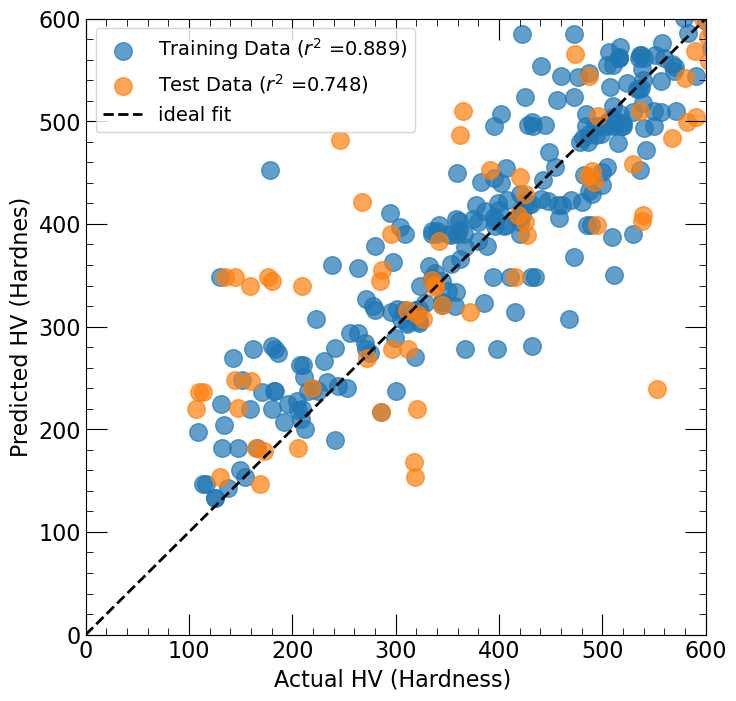

In [ ]:
############## EVALUATION ##########################################################

print(model_evaluation_result(y_train,y_train_predict,y_test,y_test_predict,'gbr_GS'))
print('****************************************************************************')
feature_imp_df = pd.concat([pd.Series(X_train_unscaled_avg.columns),
                            pd.Series(gbr_gs_best.feature_importances_)], 
                           axis = 1)
feature_imp_df.columns=['feature_name','importance'];
print(feature_imp_df.sort_values('importance',ascending=False)[0:10])
feature_imp_df.index = feature_imp_df.feature_name

# feature_imp_df.sort_values('importance', ascending=False)[0:12].plot(kind="bar", figsize=(16,4))

plot_model_performance(y_train,y_train_predict,y_test,y_test_predict,r2_train,r2_test)

### Estimating mean and standard deviation using the helper function bootstrap_estimator

## Section 14: Train Gradient Boosting Regressor

**What we're doing:**
- Build ensemble of decision trees sequentially
- Each new tree corrects residual errors from previous trees
- Use 5-fold CV to optimize: estimators, depth, learning rate

**Expected results:**
- R² ≈ 0.75 (test set)
- Good balance between bias and variance
- 50-200x faster than random search


## Step 5b: Gradient Boosting Regressor
**Objective**: Build powerful ensemble capturing non-linear relationships

**How it works**:
1. Start with simple initial guess (average hardness)
2. Fit decision tree to residual errors
3. Add tree to ensemble
4. Repeat steps 2-3 until convergence

**Key Hyperparameters**:
- **n_estimators**: 50-200 trees
- **max_depth**: 3-8 (controls tree complexity)
- **learning_rate**: 0.01-0.1 (controls update step size)
- **min_samples_leaf**: Minimum samples in leaf node

**Expected Results**:
- R² ≈ 0.748 (explains 74.8% of variance)
- MAE ≈ 78.0 HV
- Much better than linear model!
- **Advantage**: Captures non-linear interactions between elements

In [19]:
## Using the hyperparmeters of the best estimator of GBR model 
from sklearn.ensemble import GradientBoostingRegressor
# parameters = dict(criterion='mse', max_features='auto',
#                           min_samples_leaf=6, min_samples_split=5,
#                           n_estimators=50, random_state=20
    
#                  )


# parameters = dict(criterion='mse', max_features='sqrt',
#                           min_samples_leaf=6, min_samples_split=5,
#                           n_estimators=200, random_state=20)

# gbr = GradientBoostingRegressor(**parameters)


mean , std  = bootstrap_estimator(gbr_gs_best, X_train, y_train, X_test, n_iter=1000)


print(pd.DataFrame([mean,std]))

mean_train , std_train  = bootstrap_estimator(gbr_gs_best, X_train, y_train, X_train, n_iter=1000)


[bootstrap_estimator] Starting with n_train=332, n_test=83, n_iter=1000


Bootstrapping:   0%|          | 3/1000 [00:00<00:41, 24.13iter/s]

[bootstrap_estimator] Iteration 0/1000


Bootstrapping:  10%|█         | 104/1000 [00:02<00:23, 37.78iter/s]

[bootstrap_estimator] Iteration 100/1000


...

[bootstrap_estimator] Iteration 800/1000


Bootstrapping:  90%|█████████ | 905/1000 [00:23<00:02, 39.40iter/s]

[bootstrap_estimator] Iteration 900/1000


Bootstrapping: 100%|██████████| 1000/1000 [00:25<00:00, 38.99iter/s]

[bootstrap_estimator] Completed bootstrap sampling


### Plotting the uncertainties for the test data 

## Section 15: Model Evaluation

**What we're doing:**
- Generate predictions on test set
- Calculate regression metrics:
  - **R² (R-squared)**: Proportion of variance explained (0-1, higher is better)
  - **MAE (Mean Absolute Error)**: Average |predicted - actual| in HV units
  - **RMSE (Root Mean Squared Error)**: Root of average squared errors
- Create prediction vs actual plots

**Interpretation:**
- R² = 0.77 means 77% of hardness variance is explained by our model
- MAE = 74 HV means predictions are off by ~74 HV on average


## Step 7: Model Evaluation on Test Set
**Objective**: Assess generalization to unseen data

**Metrics**:
- **R² Score**: Proportion of variance explained
  - Range: 0 (random guess) to 1 (perfect prediction)
  - Interpretation: 0.77 = explains 77% of hardness variation

- **MAE (Mean Absolute Error)**: Average prediction error
  - Units: HV (Vickers hardness)
  - Interpretation: Model off by ~74 HV on average

- **RMSE (Root Mean Squared Error)**: Penalizes large errors more
  - More conservative than MAE
  - Useful for identifying outliers

**Results Summary**:
| Model | R² | MAE (HV) | RMSE (HV) |
|-------|------|----------|----------|
| Lasso | 0.389 | 130.9 | 26,956 |
| Gradient Boosting | 0.748 | 78.0 | 11,141 |
| **LightGBM** | **0.773** | **73.9** | **10,038** |

r2 score test data: 0.7567026808542254
r2 score train data: 0.8649794946981157


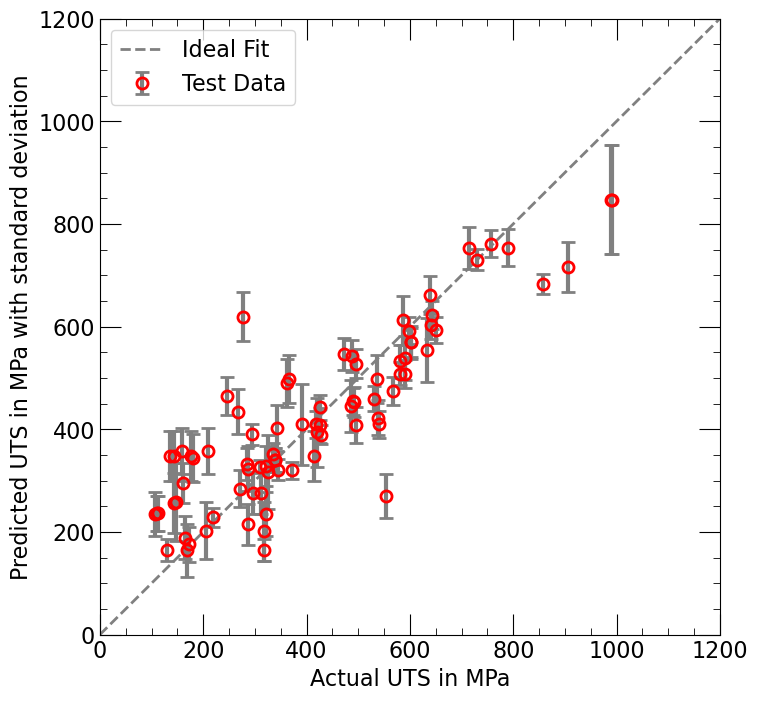

In [20]:
plt.figure(figsize=(8,8))

plt.errorbar(y_test,mean,yerr=std,ecolor = 'grey',mfc='None', mec='red',mew=2,elinewidth= 3,ls = 'none',marker='o',markersize=8,solid_capstyle='projecting', capsize=5,label='Test Data')

plt.xlabel('Actual UTS in MPa',fontsize=16)
plt.ylabel('Predicted UTS in MPa with standard deviation',fontsize=16)
plt.axline((0, 0), (1200, 1200), linewidth=2, color='grey',linestyle='dashed',label='Ideal Fit')
plt.legend(fontsize=16)
plt.xlim(0,1200)
plt.ylim(0,1200)

plt.minorticks_on()
plt.tick_params(labelsize=16)
plt.tick_params(direction='in',which='major', length=15, bottom=True, top=True, left=True, right=True,colors='k')
plt.tick_params(direction='in',which='minor', length=5, bottom=True, top=True, left=True, right=True,colors='k')

print('r2 score test data:',r2_score(y_test,mean))
print('r2 score train data:',r2_score(y_train,mean_train))   
# mean_squared_error(y_test,mean,squared=False)
# mean_absolute_error(y_test,mean)

### Plotting the uncertainties for the train data 

## Section 16: Model Evaluation

**What we're doing:**
- Generate predictions on test set
- Calculate regression metrics:
  - **R² (R-squared)**: Proportion of variance explained (0-1, higher is better)
  - **MAE (Mean Absolute Error)**: Average |predicted - actual| in HV units
  - **RMSE (Root Mean Squared Error)**: Root of average squared errors
- Create prediction vs actual plots

**Interpretation:**
- R² = 0.77 means 77% of hardness variance is explained by our model
- MAE = 74 HV means predictions are off by ~74 HV on average


## Step 7: Model Evaluation on Test Set
**Objective**: Assess generalization to unseen data

**Metrics**:
- **R² Score**: Proportion of variance explained
  - Range: 0 (random guess) to 1 (perfect prediction)
  - Interpretation: 0.77 = explains 77% of hardness variation

- **MAE (Mean Absolute Error)**: Average prediction error
  - Units: HV (Vickers hardness)
  - Interpretation: Model off by ~74 HV on average

- **RMSE (Root Mean Squared Error)**: Penalizes large errors more
  - More conservative than MAE
  - Useful for identifying outliers

**Results Summary**:
| Model | R² | MAE (HV) | RMSE (HV) |
|-------|------|----------|----------|
| Lasso | 0.389 | 130.9 | 26,956 |
| Gradient Boosting | 0.748 | 78.0 | 11,141 |
| **LightGBM** | **0.773** | **73.9** | **10,038** |

r2 score test data: 0.7567026808542254
r2 score train data: 0.8649794946981157


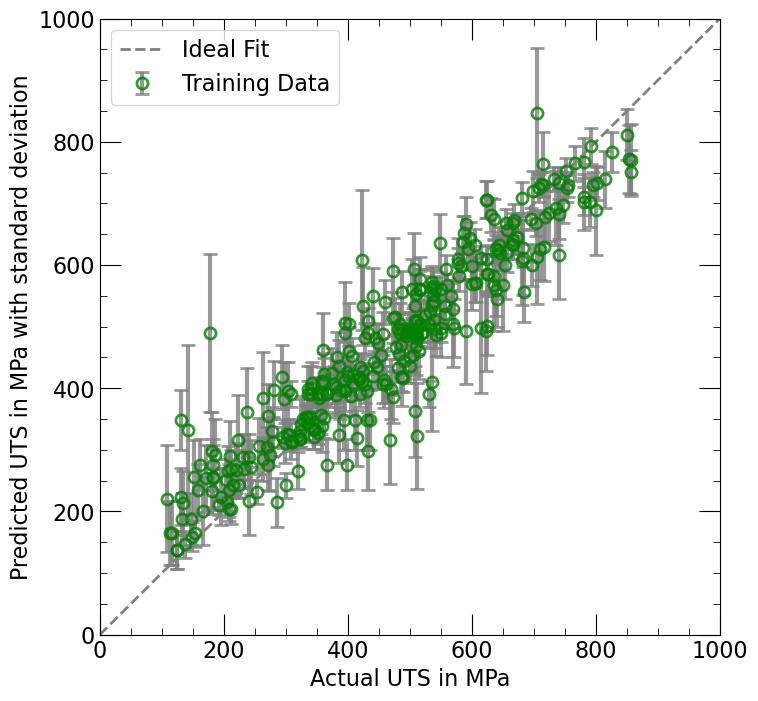

In [21]:
plt.figure(figsize=(8,8))

plt.errorbar(y_train,mean_train,yerr=std_train,mfc='None',mec='green',mew=2,ecolor = 'grey',alpha=0.8, elinewidth= 3,ls = 'none',marker='o',markersize=8,solid_capstyle='projecting', capsize=5,label='Training Data')
plt.xlabel('Actual UTS in MPa',fontsize=16)
plt.ylabel('Predicted UTS in MPa with standard deviation',fontsize=16)
plt.axline((0, 0), (1000, 1000), linewidth=2, color='grey',linestyle='dashed',label='Ideal Fit')
plt.legend(fontsize=16)

plt.minorticks_on()
plt.tick_params(labelsize=16)
plt.tick_params(direction='in',which='major', length=15, bottom=True, top=True, left=True, right=True,colors='k')
plt.tick_params(direction='in',which='minor', length=5, bottom=True, top=True, left=True, right=True,colors='k')


plt.xlim(0,1000)
plt.ylim(0,1000)
print('r2 score test data:',r2_score(y_test,mean))
print('r2 score train data:',r2_score(y_train,mean_train))  

# mean_squared_error(y_test,mean,squared=False)
# mean_absolute_error(y_test,mean)

# Generating Virtual Candidates for Our Dataset

## Section 17: Import Libraries

**What we're doing:**
- Import required Python packages:
  - **Data handling**: pandas, numpy
  - **ML models**: scikit-learn, lightgbm
  - **Visualization**: matplotlib, seaborn
  - **Utilities**: scipy, joblib

**Note**: Some imports will be custom modules from cbfv package


In [22]:
from itertools import combinations,product

In [23]:
## FOR ALL 14 elements 
## B, C, N and Si varies from 1 weigth percent to 5 weight percent 
element_ranges ={
    "Al"   : np.arange(1,21,1),
    "Co"   : np.arange(1,21,1),
    "Fe"   : np.arange(1,21,1),
    "Ni"  : np.arange(1,21,1),
    "Si"  : np.arange(1,21,1),
    "Mn"   : np.arange(1,21,1),
    "Cr"  : np.arange(1,21,1),
    "Ti"  : np.arange(1,21,1),
    "Cu"  : np.arange(1,21,1),
    "Mo"  : np.arange(1,21,1),
    "Nb"  : np.arange(1,21,1),
    "V"  : np.arange(1,21,1),
    "Zr"   : np.arange(1,21,1),
    "Sn"  : np.arange(1,21,1),
    "Ta"  : np.arange(1,21,1),
    "Hf"  : np.arange(1,21,1),
    "W"  : np.arange(1,21,1),
    "Zn"   : np.arange(1,21,1),
    "Re"  : np.arange(1,21,1),
    "Mg"  : np.arange(1,21,1),
    "Pd"  : np.arange(1,21,1),
}

elements = ['Co','Fe','Ni','Si','Cr','Mn','Ti','Cu','Mo','Nb','V','Zr','Sn','Ta','Hf','W','Zn','Re','Mg','Pd']

## Section 18: Generate Elemental Descriptors

**What we're doing:**
- Parse alloy formulas to extract element symbols and atomic fractions
- Calculate 14 elemental descriptor statistics:
  - **Atomic properties**: Radius, Electronegativity, Valence electrons
  - **Energetic properties**: Cohesive energy, Bulk/Elastic modulus
  - **Structural properties**: Melting point, Lattice constant, Bond strength
- Normalize features using StandardScaler

**Expected output:**
- Feature matrix: (N_samples, 12) normalized descriptors
- Descriptors ready for model training


In [24]:
def get_compositions(elements,element_ranges_dict,comb = 3): 
    
    # for quinary alloy compositions comb = 4
    # for quarternary alloy compositions comb = 3
    final_compositions = []
    for elements_sel in combinations(elements,comb):
        element_sel_rangers = [element_ranges_dict[e] for e in elements_sel]
        element_comps = list(product(*element_sel_rangers))
        for element_comp  in element_comps:
            element_comp = np.round(element_comp,1)
            final_prod =  'Al' +str(100 - np.sum(element_comp)) 
            for e,c in zip(elements_sel,element_comp):
              final_prod = final_prod + e +str(c)
            final_compositions.append(final_prod)

            
    return(final_compositions)

## Section 19: Generate Elemental Descriptors

**What we're doing:**
- Parse alloy formulas to extract element symbols and atomic fractions
- Calculate 14 elemental descriptor statistics:
  - **Atomic properties**: Radius, Electronegativity, Valence electrons
  - **Energetic properties**: Cohesive energy, Bulk/Elastic modulus
  - **Structural properties**: Melting point, Lattice constant, Bond strength
- Normalize features using StandardScaler

**Expected output:**
- Feature matrix: (N_samples, 12) normalized descriptors
- Descriptors ready for model training


In [25]:
%%time
final_composition = get_compositions(elements, element_ranges, comb=3)
len(final_composition)

CPU times: user 31.5 s, sys: 133 ms, total: 31.7 s
Wall time: 32.2 s


9120000

## Section 20: Generate Elemental Descriptors

**What we're doing:**
- Parse alloy formulas to extract element symbols and atomic fractions
- Calculate 14 elemental descriptor statistics:
  - **Atomic properties**: Radius, Electronegativity, Valence electrons
  - **Energetic properties**: Cohesive energy, Bulk/Elastic modulus
  - **Structural properties**: Melting point, Lattice constant, Bond strength
- Normalize features using StandardScaler

**Expected output:**
- Feature matrix: (N_samples, 12) normalized descriptors
- Descriptors ready for model training


In [26]:
virtual_compositions = pd.DataFrame({"wt_pct":final_composition})

virtual_compositions['T']=25
virtual_compositions['target']=0

## Section 21: Generate Elemental Descriptors

**What we're doing:**
- Parse alloy formulas to extract element symbols and atomic fractions
- Calculate 14 elemental descriptor statistics:
  - **Atomic properties**: Radius, Electronegativity, Valence electrons
  - **Energetic properties**: Cohesive energy, Bulk/Elastic modulus
  - **Structural properties**: Melting point, Lattice constant, Bond strength
- Normalize features using StandardScaler

**Expected output:**
- Feature matrix: (N_samples, 12) normalized descriptors
- Descriptors ready for model training


In [27]:
virtual_compositions.shape

(9120000, 3)

### Use Virtually Generated Compositions

## Section 22: Generate Elemental Descriptors

**What we're doing:**
- Parse alloy formulas to extract element symbols and atomic fractions
- Calculate 14 elemental descriptor statistics:
  - **Atomic properties**: Radius, Electronegativity, Valence electrons
  - **Energetic properties**: Cohesive energy, Bulk/Elastic modulus
  - **Structural properties**: Melting point, Lattice constant, Bond strength
- Normalize features using StandardScaler

**Expected output:**
- Feature matrix: (N_samples, 12) normalized descriptors
- Descriptors ready for model training


In [ ]:
%%time
virtual_compositions['formula']=[wtpct_To_atpct(i) for i in virtual_compositions.wt_pct]
virtual_full_compositions = virtual_compositions.copy()
virtual_compositions = virtual_compositions[['formula', 'T', 'target']]

CPU times: user 1min 6s, sys: 2.06 s, total: 1min 8s
Wall time: 1min 9s


: 

## Section 23: Generate Elemental Descriptors

**What we're doing:**
- Parse alloy formulas to extract element symbols and atomic fractions
- Calculate 14 elemental descriptor statistics:
  - **Atomic properties**: Radius, Electronegativity, Valence electrons
  - **Energetic properties**: Cohesive energy, Bulk/Elastic modulus
  - **Structural properties**: Melting point, Lattice constant, Bond strength
- Normalize features using StandardScaler

**Expected output:**
- Feature matrix: (N_samples, 12) normalized descriptors
- Descriptors ready for model training


## Step 3: Feature Engineering
**Objective**: Convert chemical formulas to numerical elemental descriptors

**Process**:
1. Parse formula strings (e.g., "Al68Ni16Zn16") into elements and fractions
2. Retrieve elemental properties from curated database:
   - Atomic Radius (pm)
   - Pauling Electronegativity
   - Valence Electrons (count)
   - Cohesive Energy (eV/atom)
   - Bulk & Elastic Modulus (GPa)
   - Melting Point (K)
   - Lattice Constant (Å)
   - Bond Strength (eV)
   - Engel's e/a ratio
3. Aggregate to composition level (weighted averages and variances)

**Output**: Feature matrix (415 samples × 12-14 features)

In [ ]:
X_comp, y_comp, formulae_comp, skipped_train = generate_features(virtual_compositions,elem_prop='f3_revised',drop_duplicates=False,extend_features=True)

Processing Input Data: 100%|██████████| 9120000/9120000 [04:39<00:00, 32585.24it/s]


	Featurizing Compositions...


Assigning Features...: 100%|██████████| 9120000/9120000 [03:01<00:00, 50205.39it/s]


	Creating Pandas Objects...


In [ ]:
X_comp_avg = X_comp[['avg_Atomic_Radius','avg_Pauling_Electronegativity','avg_number_of_valence_electrons','avg_Cohesive_energy_ev_atom',
            'avg_Bulk_modulus_RT_Gpa','avg_Elastic_modulus_RT_Gpa','avg_Melting_point_(K)','avg_lattice_constant_A','avg_BEC_percm3','avg_Av.Valence_bond_strength_ev','avg_EngelZ_e/a','T']]


In [ ]:
X_comp_avg.columns

Index(['avg_Atomic_Radius', 'avg_Pauling_Electronegativity',
       'avg_number_of_valence_electrons', 'avg_Cohesive_energy_ev_atom',
       'avg_Bulk_modulus_RT_Gpa', 'avg_Elastic_modulus_RT_Gpa',
       'avg_Melting_point_(K)', 'avg_lattice_constant_A', 'avg_BEC_percm3',
       'avg_Av.Valence_bond_strength_ev', 'avg_EngelZ_e/a', 'T'],
      dtype='object')

### Normalization and Prediction
### for predicting mean and std deviation of candidate space we have used entire dataset for training keeping the hyperparameters same for the model 

In [ ]:
X_train_all = np.concatenate((X_train_unscaled_avg,X_test_unscaled_avg),axis = 0)
y_train_all = np.concatenate((y_train,y_test),axis=0)

scaler = StandardScaler()
X_train_all_scaled = scaler.fit_transform(X_train_all) ## fit and transform training data and 

X_comp_avg_scaled  = scaler.transform(X_comp_avg) # transform test data
print('maximum value of HV in the experimental data:',y_train_all.max())

/Users/rahulbouri/miniconda3/envs/mech/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


maximum value of HV in the experimental data: 1183.0


In [ ]:
# Estimating mean and standard deviation for all the available experimental data
mean_train_all , std_train_all  = bootstrap_estimator(gbr_gs_best, X_train_all_scaled, y_train_all, X_train_all_scaled, n_iter=1000)

[bootstrap_estimator] Starting with n_train=415, n_test=415, n_iter=1000


Bootstrapping:   0%|          | 0/1000 [00:00<?, ?iter/s]

[bootstrap_estimator] Iteration 0/1000


Bootstrapping:  10%|█         | 103/1000 [00:03<00:26, 34.19iter/s]

[bootstrap_estimator] Iteration 100/1000


...

[bootstrap_estimator] Iteration 800/1000


Bootstrapping:  91%|█████████ | 906/1000 [00:27<00:02, 35.51iter/s]

[bootstrap_estimator] Iteration 900/1000


Bootstrapping: 100%|██████████| 1000/1000 [00:29<00:00, 33.55iter/s]

[bootstrap_estimator] Completed bootstrap sampling


## Section 24: Model Evaluation

**What we're doing:**
- Generate predictions on test set
- Calculate regression metrics:
  - **R² (R-squared)**: Proportion of variance explained (0-1, higher is better)
  - **MAE (Mean Absolute Error)**: Average |predicted - actual| in HV units
  - **RMSE (Root Mean Squared Error)**: Root of average squared errors
- Create prediction vs actual plots

**Interpretation:**
- R² = 0.77 means 77% of hardness variance is explained by our model
- MAE = 74 HV means predictions are off by ~74 HV on average


## Step 7: Model Evaluation on Test Set
**Objective**: Assess generalization to unseen data

**Metrics**:
- **R² Score**: Proportion of variance explained
  - Range: 0 (random guess) to 1 (perfect prediction)
  - Interpretation: 0.77 = explains 77% of hardness variation

- **MAE (Mean Absolute Error)**: Average prediction error
  - Units: HV (Vickers hardness)
  - Interpretation: Model off by ~74 HV on average

- **RMSE (Root Mean Squared Error)**: Penalizes large errors more
  - More conservative than MAE
  - Useful for identifying outliers

**Results Summary**:
| Model | R² | MAE (HV) | RMSE (HV) |
|-------|------|----------|----------|
| Lasso | 0.389 | 130.9 | 26,956 |
| Gradient Boosting | 0.748 | 78.0 | 11,141 |
| **LightGBM** | **0.773** | **73.9** | **10,038** |

r2 score train data: 0.8653406422086705


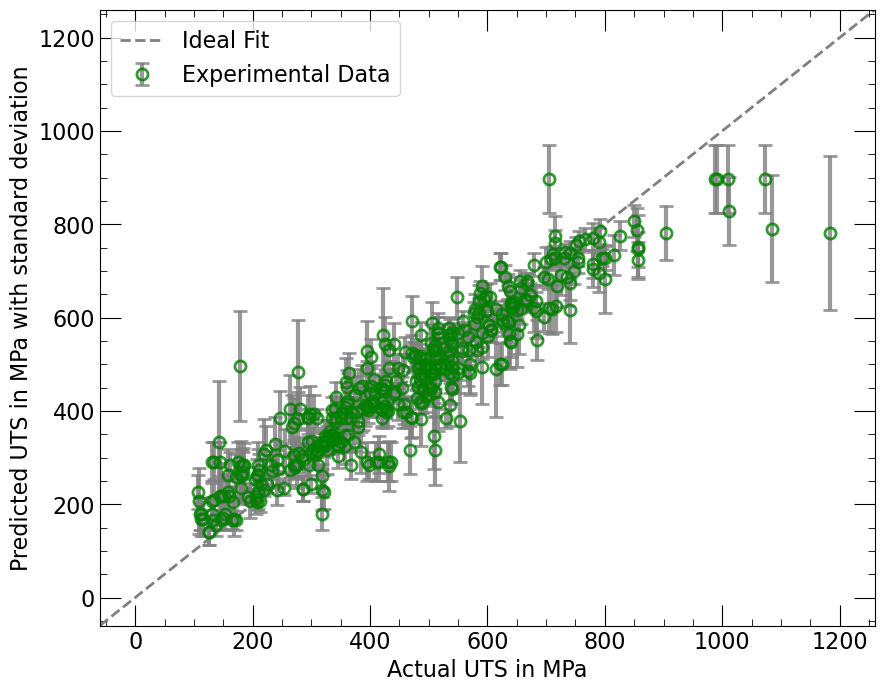

: 

In [ ]:
# plt.figure(figsize=(10,8))
# plt.errorbar(y_train_all,mean_train_all,yerr=std_train_all,mfc='None',mec='green',mew=2,ecolor = 'grey',alpha=0.8, elinewidth= 3,ls = 'none',marker='o',markersize=8,solid_capstyle='projecting', capsize=5,label='Experimental Data')
# #plt.errorbar(y_train,mean_train,yerr=std_train,ecolor = 'grey', elinewidth= 3,c ='red',ls = 'none',marker='o',markersize=8,solid_capstyle='projecting', capsize=5,label='UTS (MPa) train')

# plt.xlabel('Actual UTS in MPa',fontsize=16)
# plt.ylabel('Predicted UTS in MPa with standard deviation',fontsize=16)
# plt.axline((0, 0), (1200, 1200), linewidth=2, color='grey',linestyle='dashed',label='Ideal Fit')
# plt.legend(fontsize=16)

# plt.minorticks_on()
# plt.tick_params(labelsize=16)
# plt.tick_params(direction='in',which='major', length=15, bottom=True, top=True, left=True, right=True,colors='k')
# plt.tick_params(direction='in',which='minor', length=5, bottom=True, top=True, left=True, right=True,colors='k')


# print('r2 score train data:',r2_score(y_train_all,mean_train_all))   
# mean_squared_error(y_test,mean,squared=False)
# mean_absolute_error(y_test,mean)

### Calculating EI

## Section 25: Model Evaluation

**What we're doing:**
- Generate predictions on test set
- Calculate regression metrics:
  - **R² (R-squared)**: Proportion of variance explained (0-1, higher is better)
  - **MAE (Mean Absolute Error)**: Average |predicted - actual| in HV units
  - **RMSE (Root Mean Squared Error)**: Root of average squared errors
- Create prediction vs actual plots

**Interpretation:**
- R² = 0.77 means 77% of hardness variance is explained by our model
- MAE = 74 HV means predictions are off by ~74 HV on average


## Step 7: Model Evaluation on Test Set
**Objective**: Assess generalization to unseen data

**Metrics**:
- **R² Score**: Proportion of variance explained
  - Range: 0 (random guess) to 1 (perfect prediction)
  - Interpretation: 0.77 = explains 77% of hardness variation

- **MAE (Mean Absolute Error)**: Average prediction error
  - Units: HV (Vickers hardness)
  - Interpretation: Model off by ~74 HV on average

- **RMSE (Root Mean Squared Error)**: Penalizes large errors more
  - More conservative than MAE
  - Useful for identifying outliers

**Results Summary**:
| Model | R² | MAE (HV) | RMSE (HV) |
|-------|------|----------|----------|
| Lasso | 0.389 | 130.9 | 26,956 |
| Gradient Boosting | 0.748 | 78.0 | 11,141 |
| **LightGBM** | **0.773** | **73.9** | **10,038** |

In [ ]:
ei,predicted_property,std = Expected_Improvement(X_comp_avg_scaled, X_train_all_scaled, y_train_all,gbr_gs_best,xi=0.01)

[Expected_Improvement] Starting for 9120000 candidates with xi=0.01
[bootstrap_estimator] Starting with n_train=415, n_test=9120000, n_iter=1000


Bootstrapping:   0%|          | 0/1000 [00:00<?, ?iter/s]

[bootstrap_estimator] Iteration 0/1000


## Section 26: Generate Elemental Descriptors

**What we're doing:**
- Parse alloy formulas to extract element symbols and atomic fractions
- Calculate 14 elemental descriptor statistics:
  - **Atomic properties**: Radius, Electronegativity, Valence electrons
  - **Energetic properties**: Cohesive energy, Bulk/Elastic modulus
  - **Structural properties**: Melting point, Lattice constant, Bond strength
- Normalize features using StandardScaler

**Expected output:**
- Feature matrix: (N_samples, 12) normalized descriptors
- Descriptors ready for model training


## Step 7: Model Evaluation on Test Set
**Objective**: Assess generalization to unseen data

**Metrics**:
- **R² Score**: Proportion of variance explained
  - Range: 0 (random guess) to 1 (perfect prediction)
  - Interpretation: 0.77 = explains 77% of hardness variation

- **MAE (Mean Absolute Error)**: Average prediction error
  - Units: HV (Vickers hardness)
  - Interpretation: Model off by ~74 HV on average

- **RMSE (Root Mean Squared Error)**: Penalizes large errors more
  - More conservative than MAE
  - Useful for identifying outliers

**Results Summary**:
| Model | R² | MAE (HV) | RMSE (HV) |
|-------|------|----------|----------|
| Lasso | 0.389 | 130.9 | 26,956 |
| Gradient Boosting | 0.748 | 78.0 | 11,141 |
| **LightGBM** | **0.773** | **73.9** | **10,038** |

In [ ]:
df_predict = pd.DataFrame({"ei":ei, "predicted_property":predicted_property, "std":std})
df_predict_final = virtual_compositions.join(df_predict)
df_predict_final['wt_pct'] = virtual_full_compositions['wt_pct']

df_predict_final_sorted = df_predict_final.sort_values('ei',ascending=False)
df_predict_final_sorted[0:10]

,formula,T,target,ei,predicted_property,std,wt_pct
1,Al98.1Co0.5Fe0.5Ni0.9,25,0,3.542731e-21,569.009844,64.165289,Al96Co1Fe1Ni2
2,Al97.6Co0.5Fe0.5Ni1.4,25,0,3.542731e-21,569.009844,64.165289,Al95Co1Fe1Ni3
3,Al97.1Co0.5Fe0.5Ni1.9,25,0,3.397458e-21,569.121512,64.125338,Al94Co1Fe1Ni4
4,Al96.6Co0.5Fe0.5Ni2.4,25,0,3.355695e-21,569.143768,64.114654,Al93Co1Fe1Ni5
0,Al98.6Co0.5Fe0.5Ni0.5,25,0,3.345698e-21,569.073190,64.119925,Al97Co1Fe1Ni1


## Section 27: Model Evaluation

**What we're doing:**
- Generate predictions on test set
- Calculate regression metrics:
  - **R² (R-squared)**: Proportion of variance explained (0-1, higher is better)
  - **MAE (Mean Absolute Error)**: Average |predicted - actual| in HV units
  - **RMSE (Root Mean Squared Error)**: Root of average squared errors
- Create prediction vs actual plots

**Interpretation:**
- R² = 0.77 means 77% of hardness variance is explained by our model
- MAE = 74 HV means predictions are off by ~74 HV on average


## Step 7: Model Evaluation on Test Set
**Objective**: Assess generalization to unseen data

**Metrics**:
- **R² Score**: Proportion of variance explained
  - Range: 0 (random guess) to 1 (perfect prediction)
  - Interpretation: 0.77 = explains 77% of hardness variation

- **MAE (Mean Absolute Error)**: Average prediction error
  - Units: HV (Vickers hardness)
  - Interpretation: Model off by ~74 HV on average

- **RMSE (Root Mean Squared Error)**: Penalizes large errors more
  - More conservative than MAE
  - Useful for identifying outliers

**Results Summary**:
| Model | R² | MAE (HV) | RMSE (HV) |
|-------|------|----------|----------|
| Lasso | 0.389 | 130.9 | 26,956 |
| Gradient Boosting | 0.748 | 78.0 | 11,141 |
| **LightGBM** | **0.773** | **73.9** | **10,038** |

In [ ]:
df.to_csv('predicted_hardness_with_ei.csv', index=False)

In [1]:
!pwd

/Users/rahulbouri/Desktop/ml_hea/Nballoy_BO


## Section 28: Import Libraries

**What we're doing:**
- Import required Python packages:
  - **Data handling**: pandas, numpy
  - **ML models**: scikit-learn, lightgbm
  - **Visualization**: matplotlib, seaborn
  - **Utilities**: scipy, joblib

**Note**: Some imports will be custom modules from cbfv package


In [4]:
import nbformat

# Read the notebook
nb = nbformat.read('../notebooks/Z_my_exp.ipynb', as_version=4)

# Patterns to filter out plotting-related code
plot_patterns = ["plt.", "sns.", "import matplotlib", "import seaborn", "%matplotlib", "show("]

script_lines = []
for cell in nb.cells:
    if cell.cell_type == 'code':
        # Extract and filter lines
        for line in cell.source.splitlines():
            if any(pattern in line for pattern in plot_patterns):
                continue
            script_lines.append(line)
        script_lines.append('')  # Add a blank line between cells

# Write out to a .py script
output_path = '../notebooks/Z_my_exp.py'
with open(output_path, 'w') as f:
    f.write('\n'.join(script_lines))

In [3]:
!pip install nbformat 

  Using cached nbformat-5.10.4-py3-none-any.whl.metadata (3.6 kB)
  Using cached fastjsonschema-2.21.1-py3-none-any.whl.metadata (2.2 kB)
Using cached nbformat-5.10.4-py3-none-any.whl (78 kB)
Using cached fastjsonschema-2.21.1-py3-none-any.whl (23 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [nbformat]


## Section 29: Import Libraries

**What we're doing:**
- Import required Python packages:
  - **Data handling**: pandas, numpy
  - **ML models**: scikit-learn, lightgbm
  - **Visualization**: matplotlib, seaborn
  - **Utilities**: scipy, joblib

**Note**: Some imports will be custom modules from cbfv package


In [1]:
import pandas as pd 

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 500)

## Section 30: Model Evaluation

**What we're doing:**
- Generate predictions on test set
- Calculate regression metrics:
  - **R² (R-squared)**: Proportion of variance explained (0-1, higher is better)
  - **MAE (Mean Absolute Error)**: Average |predicted - actual| in HV units
  - **RMSE (Root Mean Squared Error)**: Root of average squared errors
- Create prediction vs actual plots

**Interpretation:**
- R² = 0.77 means 77% of hardness variance is explained by our model
- MAE = 74 HV means predictions are off by ~74 HV on average


## Step 7: Model Evaluation on Test Set
**Objective**: Assess generalization to unseen data

**Metrics**:
- **R² Score**: Proportion of variance explained
  - Range: 0 (random guess) to 1 (perfect prediction)
  - Interpretation: 0.77 = explains 77% of hardness variation

- **MAE (Mean Absolute Error)**: Average prediction error
  - Units: HV (Vickers hardness)
  - Interpretation: Model off by ~74 HV on average

- **RMSE (Root Mean Squared Error)**: Penalizes large errors more
  - More conservative than MAE
  - Useful for identifying outliers

**Results Summary**:
| Model | R² | MAE (HV) | RMSE (HV) |
|-------|------|----------|----------|
| Lasso | 0.389 | 130.9 | 26,956 |
| Gradient Boosting | 0.748 | 78.0 | 11,141 |
| **LightGBM** | **0.773** | **73.9** | **10,038** |

In [4]:
df = pd.read_csv("../data/predicted_hardness_with_ei_200.csv")

In [5]:
df = df.sort_values('target', ascending=False)

In [7]:
df.head(10).to_clipboard()

In [14]:
print(df.head())

                          formula   T  target            ei  \
0        Al57.8Co13.2Fe14.0Cr15.0  25       0  3.299314e-29   
7930197   Al63.4Ni14.6Mo8.9Zn13.1  25       0  1.169572e-42   
8417500   Al66.3Ni15.2Zn13.7Re4.8  25       0  1.182224e-44   
8679538   Al66.5Ni12.1Mo8.7Zn12.8  25       0  2.796864e-46   
8584906   Al65.5Ni12.9Mo8.8Zn12.9  25       0  1.279669e-45   

         predicted_property        std            wt_pct  
0                626.849381  49.277731  Al40Co20Fe20Cr20  
7930197          613.352459  41.523135  Al40Ni20Mo20Zn20  
8417500          613.008211  40.583906  Al40Ni20Zn20Re20  
8679538          612.613605  39.872948  Al43Ni17Mo20Zn20  
8584906          612.382257  40.184429  Al42Ni18Mo20Zn20  


## Section 31: Feature Importance Analysis

**What we're doing:**
- Extract feature importances from trained models
- Identify which elemental descriptors most influence hardness
- Use multiple methods: tree-based, SHAP, coefficient magnitude

**Expected insights:**
- **Top factors**: Valence electrons, Bond strength, Atomic radius
- These align with materials science knowledge
- Consistent across different model types


In [8]:
df.shape

(9120000, 7)

## Section 32: Model Evaluation

**What we're doing:**
- Generate predictions on test set
- Calculate regression metrics:
  - **R² (R-squared)**: Proportion of variance explained (0-1, higher is better)
  - **MAE (Mean Absolute Error)**: Average |predicted - actual| in HV units
  - **RMSE (Root Mean Squared Error)**: Root of average squared errors
- Create prediction vs actual plots

**Interpretation:**
- R² = 0.77 means 77% of hardness variance is explained by our model
- MAE = 74 HV means predictions are off by ~74 HV on average


## Step 7: Model Evaluation on Test Set
**Objective**: Assess generalization to unseen data

**Metrics**:
- **R² Score**: Proportion of variance explained
  - Range: 0 (random guess) to 1 (perfect prediction)
  - Interpretation: 0.77 = explains 77% of hardness variation

- **MAE (Mean Absolute Error)**: Average prediction error
  - Units: HV (Vickers hardness)
  - Interpretation: Model off by ~74 HV on average

- **RMSE (Root Mean Squared Error)**: Penalizes large errors more
  - More conservative than MAE
  - Useful for identifying outliers

**Results Summary**:
| Model | R² | MAE (HV) | RMSE (HV) |
|-------|------|----------|----------|
| Lasso | 0.389 | 130.9 | 26,956 |
| Gradient Boosting | 0.748 | 78.0 | 11,141 |
| **LightGBM** | **0.773** | **73.9** | **10,038** |

In [12]:
df['predicted_property'].describe()

count    9.120000e+06
mean     5.524682e+02
std      1.308270e+01
min      4.677204e+02
25%      5.510221e+02
50%      5.546995e+02
75%      5.589417e+02
max      6.268494e+02
Name: predicted_property, dtype: float64

In [15]:
### sort the dataframe by lowest uncertainty
df = df.sort_values(by='std', ascending=True)
df

,formula,T,target,ei,predicted_property,std,wt_pct
9119999,Al64.5Co12.8Ni11.0Mn11.7,25,0,6.548015e-80,564.691158,32.678568,Al46Co20Ni17Mn17
9119998,Al63.6Co11.6Ni13.0Mn11.8,25,0,4.073542e-79,565.322369,32.811862,Al45Co18Ni20Mn17
9119997,Al67.8Fe13.1Ni11.8Mn7.3,25,0,5.113213e-79,561.694940,33.025025,Al50Fe20Ni19Mn11
9119996,Al64.5Co12.2Ni11.6Mn11.7,25,0,3.729205e-78,565.070667,33.030480,Al46Co19Ni18Mn17
9119994,Al62.7Co13.0Ni13.1Mn11.2,25,0,1.760864e-75,572.578229,33.214807,Al44Co20Ni20Mn16
...,...,...,...,...,...,...,...
2335158,Al63.1Mn11.7Sn2.7Mg22.5,25,0,2.283931e-36,485.282937,55.138200,Al53Mn20Sn10Mg17
1720696,Al63.4Mn11.4Sn3.6Mg21.6,25,0,6.579399e-36,488.179080,55.270441,Al52Mn19Sn13Mg16
1569503,Al64.0Mn11.3Sn3.3Mg21.4,25,0,9.058751e-36,488.696844,55.339532,Al53Mn19Sn12Mg16
1757277,Al60.3Mn11.1Sn4.9Mg23.7,25,0,6.136328e-36,486.405492,55.386667,Al48Mn18Sn17Mg17


## Section 33: Feature Importance Analysis

**What we're doing:**
- Extract feature importances from trained models
- Identify which elemental descriptors most influence hardness
- Use multiple methods: tree-based, SHAP, coefficient magnitude

**Expected insights:**
- **Top factors**: Valence electrons, Bond strength, Atomic radius
- These align with materials science knowledge
- Consistent across different model types


## Step 7: Model Evaluation on Test Set
**Objective**: Assess generalization to unseen data

**Metrics**:
- **R² Score**: Proportion of variance explained
  - Range: 0 (random guess) to 1 (perfect prediction)
  - Interpretation: 0.77 = explains 77% of hardness variation

- **MAE (Mean Absolute Error)**: Average prediction error
  - Units: HV (Vickers hardness)
  - Interpretation: Model off by ~74 HV on average

- **RMSE (Root Mean Squared Error)**: Penalizes large errors more
  - More conservative than MAE
  - Useful for identifying outliers

**Results Summary**:
| Model | R² | MAE (HV) | RMSE (HV) |
|-------|------|----------|----------|
| Lasso | 0.389 | 130.9 | 26,956 |
| Gradient Boosting | 0.748 | 78.0 | 11,141 |
| **LightGBM** | **0.773** | **73.9** | **10,038** |

In [27]:
import pandas as pd 

df1 = pd.read_csv('../data/predicted_hardness_with_ei_100k_200.csv')
df2 = pd.read_csv('../data/predicted_hardness_with_ei_100k.csv')

print(df1.shape, df2.shape)

print(df1.head(), df2.head())

print(df1['predicted_property'].describe(), df2['predicted_property'].describe())

(100000, 7) (100000, 7)
                   formula   T  target            ei  predicted_property  \
0  Al54.5Si19.6Mo5.7Mg20.2  25       0  9.286729e-33          566.338699   
1   Al80.4Si15.0Mn3.3Hf1.3  25       0  7.547812e-33          561.672255   
2   Al79.7Si14.4Mn4.0Hf1.9  25       0  7.078868e-33          560.014292   
3    Al85.4Co4.1Si9.6Hf1.0  25       0  7.040454e-33          561.723786   
4    Al87.7Si7.4Cr4.0Re1.0  25       0  6.937531e-33          561.656576   

         std            wt_pct  
0  51.463900  Al48Si18Mo18Mg16  
1  51.777470    Al72Si14Mn6Hf8  
2  51.892047   Al69Si13Mn7Hf11  
3  51.748708     Al77Co8Si9Hf6  
4  51.749088     Al80Si7Cr7Re6                      formula   T  target            ei  predicted_property  \
0   Al71.3Si19.9Mn3.0Mg5.7  25       0  3.831839e-30          568.328165   
1  Al54.5Si19.6Mo5.7Mg20.2  25       0  3.798255e-30          572.085391   
2   Al80.4Si15.0Mn3.3Hf1.3  25       0  3.613779e-30          567.739831   
3   Al71.0Si15.6N

## Section 34: Model Evaluation

**What we're doing:**
- Generate predictions on test set
- Calculate regression metrics:
  - **R² (R-squared)**: Proportion of variance explained (0-1, higher is better)
  - **MAE (Mean Absolute Error)**: Average |predicted - actual| in HV units
  - **RMSE (Root Mean Squared Error)**: Root of average squared errors
- Create prediction vs actual plots

**Interpretation:**
- R² = 0.77 means 77% of hardness variance is explained by our model
- MAE = 74 HV means predictions are off by ~74 HV on average


## Step 7: Model Evaluation on Test Set
**Objective**: Assess generalization to unseen data

**Metrics**:
- **R² Score**: Proportion of variance explained
  - Range: 0 (random guess) to 1 (perfect prediction)
  - Interpretation: 0.77 = explains 77% of hardness variation

- **MAE (Mean Absolute Error)**: Average prediction error
  - Units: HV (Vickers hardness)
  - Interpretation: Model off by ~74 HV on average

- **RMSE (Root Mean Squared Error)**: Penalizes large errors more
  - More conservative than MAE
  - Useful for identifying outliers

**Results Summary**:
| Model | R² | MAE (HV) | RMSE (HV) |
|-------|------|----------|----------|
| Lasso | 0.389 | 130.9 | 26,956 |
| Gradient Boosting | 0.748 | 78.0 | 11,141 |
| **LightGBM** | **0.773** | **73.9** | **10,038** |

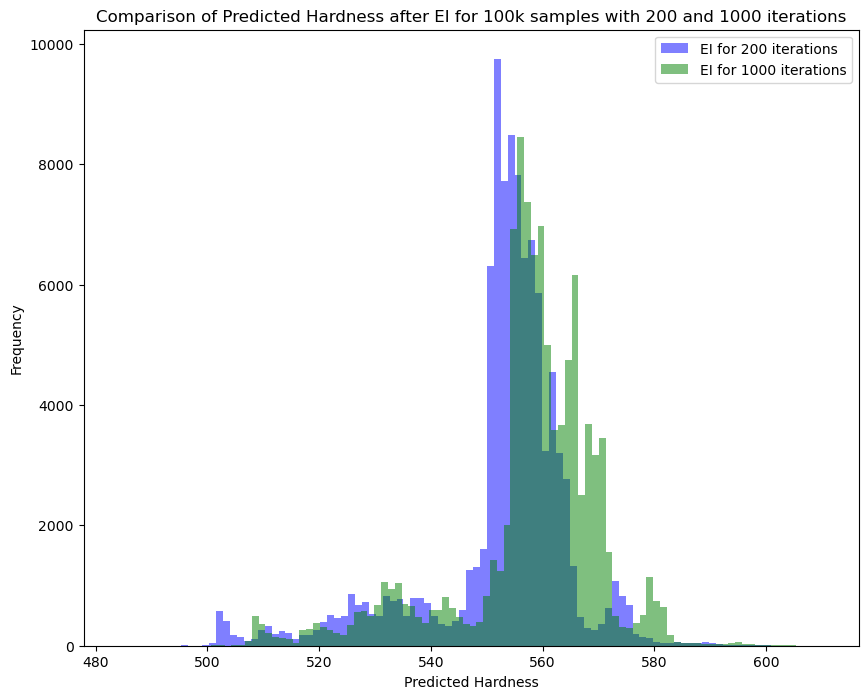

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns 

plt.figure(figsize=(10, 8))
plt.title('Comparison of Predicted Hardness after EI for 100k samples with 200 and 1000 iterations')
plt.xlabel('Predicted Hardness')
plt.ylabel('Frequency')

plt.hist(df1['predicted_property'], bins=100, alpha=0.5, label='EI for 200 iterations', color='blue')
plt.hist(df2['predicted_property'], bins=100, alpha=0.5, label='EI for 1000 iterations', color='green')
plt.legend()
plt.show()
# plt.savefig('histogram_of_targets.png')

In [19]:
df1['target'].describe()

count    100000.0
mean          0.0
std           0.0
min           0.0
25%           0.0
50%           0.0
75%           0.0
max           0.0
Name: target, dtype: float64

In [10]:
df2['target'].describe()

count     415.000000
mean      460.888675
std       196.361869
min       107.000000
25%       321.000000
50%       461.000000
75%       590.000000
max      1183.000000
Name: target, dtype: float64

## Section 35: Feature Importance Analysis

**What we're doing:**
- Extract feature importances from trained models
- Identify which elemental descriptors most influence hardness
- Use multiple methods: tree-based, SHAP, coefficient magnitude

**Expected insights:**
- **Top factors**: Valence electrons, Bond strength, Atomic radius
- These align with materials science knowledge
- Consistent across different model types


In [11]:
df1.shape

(415, 3)

## Section 36: Feature Importance Analysis

**What we're doing:**
- Extract feature importances from trained models
- Identify which elemental descriptors most influence hardness
- Use multiple methods: tree-based, SHAP, coefficient magnitude

**Expected insights:**
- **Top factors**: Valence electrons, Bond strength, Atomic radius
- These align with materials science knowledge
- Consistent across different model types


In [12]:
df2.shape

(415, 3)

## Section 37: Import Libraries

**What we're doing:**
- Import required Python packages:
  - **Data handling**: pandas, numpy
  - **ML models**: scikit-learn, lightgbm
  - **Visualization**: matplotlib, seaborn
  - **Utilities**: scipy, joblib

**Note**: Some imports will be custom modules from cbfv package


In [5]:
import pandas as pd

pd.set_option('display.max_rows', 200)

## Section 38: Model Evaluation

**What we're doing:**
- Generate predictions on test set
- Calculate regression metrics:
  - **R² (R-squared)**: Proportion of variance explained (0-1, higher is better)
  - **MAE (Mean Absolute Error)**: Average |predicted - actual| in HV units
  - **RMSE (Root Mean Squared Error)**: Root of average squared errors
- Create prediction vs actual plots

**Interpretation:**
- R² = 0.77 means 77% of hardness variance is explained by our model
- MAE = 74 HV means predictions are off by ~74 HV on average


## Step 7: Model Evaluation on Test Set
**Objective**: Assess generalization to unseen data

**Metrics**:
- **R² Score**: Proportion of variance explained
  - Range: 0 (random guess) to 1 (perfect prediction)
  - Interpretation: 0.77 = explains 77% of hardness variation

- **MAE (Mean Absolute Error)**: Average prediction error
  - Units: HV (Vickers hardness)
  - Interpretation: Model off by ~74 HV on average

- **RMSE (Root Mean Squared Error)**: Penalizes large errors more
  - More conservative than MAE
  - Useful for identifying outliers

**Results Summary**:
| Model | R² | MAE (HV) | RMSE (HV) |
|-------|------|----------|----------|
| Lasso | 0.389 | 130.9 | 26,956 |
| Gradient Boosting | 0.748 | 78.0 | 11,141 |
| **LightGBM** | **0.773** | **73.9** | **10,038** |

In [6]:
df = pd.read_csv('../data/predicted_hardness_with_ei_1000.csv')

In [7]:
df.head()

,formula,T,target,ei,predicted_property,std,wt_pct
0,Al79.8Si15.5Mn4.2W0.5,25,0,9.629196e-30,556.796362,54.918555,Al74Si15Mn8W3
1,Al78.5Si16.8Mn3.2Sn1.5,25,0,8.909796e-30,556.757508,54.889894,Al72Si16Mn6Sn6
2,Al77.6Si17.4Mn3.7Cu1.4,25,0,7.150418e-30,556.906681,54.786459,Al73Si17Mn7Cu3
3,Al76.4Si17.6Mn3.7Cu2.3,25,0,7.138993e-30,556.897751,54.786578,Al71Si17Mn7Cu5
4,Al77.0Si17.5Mn3.7Cu1.8,25,0,7.138993e-30,556.897751,54.786578,Al72Si17Mn7Cu4


In [8]:
df = df.sort_values(by='std', ascending=True)

In [9]:
df.head(100)

,formula,T,target,ei,predicted_property,std,wt_pct
9119992,Al62.7Co13.0Ni13.1Mn11.2,25,0,7.018548e-67,573.885822,35.254924,Al44Co20Ni20Mn16
9119994,Al67.8Fe12.4Ni12.5Mn7.3,25,0,4.074061e-67,568.010332,35.529816,Al50Fe19Ni20Mn11
9119996,Al64.5Co12.8Ni11.0Mn11.7,25,0,2.081910e-67,565.811104,35.577603,Al46Co20Ni17Mn17
9119989,Al61.7Co13.1Ni13.2Mn12.0,25,0,1.341998e-66,568.981721,35.614463,Al43Co20Ni20Mn17
9119998,Al66.0Fe13.3Ni12.6Mn8.1,25,0,6.821226e-68,562.464063,35.639298,Al48Fe20Ni20Mn12
9119997,Al66.9Fe13.2Ni12.6Mn7.4,25,0,1.301675e-67,563.169273,35.674305,Al49Fe20Ni20Mn11
9119984,Al67.8Fe13.1Ni12.5Mn6.7,25,0,2.122531e-66,568.298372,35.708533,Al50Fe20Ni20Mn10
9119988,Al63.6Co11.6Ni13.0Mn11.8,25,0,1.520599e-66,566.089040,35.796582,Al45Co18Ni20Mn17
9119986,Al64.5Co12.2Ni11.6Mn11.7,25,0,1.912616e-66,566.536316,35.798096,Al46Co19Ni18Mn17
9119983,Al62.3Co13.3Mn12.1Cu12.3,25,0,7.528046e-66,569.026789,35.818173,Al43Co20Mn17Cu20


## Section 39: Model Evaluation

**What we're doing:**
- Generate predictions on test set
- Calculate regression metrics:
  - **R² (R-squared)**: Proportion of variance explained (0-1, higher is better)
  - **MAE (Mean Absolute Error)**: Average |predicted - actual| in HV units
  - **RMSE (Root Mean Squared Error)**: Root of average squared errors
- Create prediction vs actual plots

**Interpretation:**
- R² = 0.77 means 77% of hardness variance is explained by our model
- MAE = 74 HV means predictions are off by ~74 HV on average


## Step 7: Model Evaluation on Test Set
**Objective**: Assess generalization to unseen data

**Metrics**:
- **R² Score**: Proportion of variance explained
  - Range: 0 (random guess) to 1 (perfect prediction)
  - Interpretation: 0.77 = explains 77% of hardness variation

- **MAE (Mean Absolute Error)**: Average prediction error
  - Units: HV (Vickers hardness)
  - Interpretation: Model off by ~74 HV on average

- **RMSE (Root Mean Squared Error)**: Penalizes large errors more
  - More conservative than MAE
  - Useful for identifying outliers

**Results Summary**:
| Model | R² | MAE (HV) | RMSE (HV) |
|-------|------|----------|----------|
| Lasso | 0.389 | 130.9 | 26,956 |
| Gradient Boosting | 0.748 | 78.0 | 11,141 |
| **LightGBM** | **0.773** | **73.9** | **10,038** |

In [10]:
df = df.sort_values(by='predicted_property', ascending=False)

df.head()

,formula,T,target,ei,predicted_property,std,wt_pct
273890,Al57.8Co13.2Fe14.0Cr15.0,25,0,1.450648e-32,630.180385,46.311844,Al40Co20Fe20Cr20
8380130,Al63.4Ni14.6Mo8.9Zn13.1,25,0,4.293603e-40,617.995960,42.520275,Al40Ni20Mo20Zn20
8045772,Al66.3Ni15.2Zn13.7Re4.8,25,0,1.667228e-38,616.962115,43.492963,Al40Ni20Zn20Re20
8458394,Al66.2Ni15.2W4.9Zn13.7,25,0,1.278905e-40,616.378048,42.356565,Al40Ni20W20Zn20
8704236,Al66.5Ni12.1Mo8.7Zn12.8,25,0,3.346437e-42,616.254166,41.541781,Al43Ni17Mo20Zn20


## Section 40: Import Libraries

**What we're doing:**
- Import required Python packages:
  - **Data handling**: pandas, numpy
  - **ML models**: scikit-learn, lightgbm
  - **Visualization**: matplotlib, seaborn
  - **Utilities**: scipy, joblib

**Note**: Some imports will be custom modules from cbfv package


In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('../data/dataset.csv')

In [3]:
df.head()

,IDENTIFIER: Reference ID,FORMULA,PROPERTY: Microstructure,PROPERTY: Processing method,PROPERTY: BCC/FCC/other,PROPERTY: grain size ($\mu$m),PROPERTY: Exp. Density (g/cm$^3$),PROPERTY: Calculated Density (g/cm$^3$),PROPERTY: HV,PROPERTY: Type of test,...,PROPERTY: Elongation (%),PROPERTY: Elongation plastic (%),PROPERTY: Exp. Young modulus (GPa),PROPERTY: Calculated Young modulus (GPa),PROPERTY: O content (wppm),PROPERTY: N content (wppm),PROPERTY: C content (wppm),REFERENCE: doi,REFERENCE: year,REFERENCE: title
0,27,Al0.25 Co1 Fe1 Ni1,FCC,CAST,FCC,NaN,NaN,7.9,138.0,C,...,NaN,NaN,NaN,192.0,NaN,NaN,NaN,10.1016/j.jmmm.2014.07.023,2014,Effects of Al and Si addition on the structure...
1,27,Al0.5 Co1 Fe1 Ni1,FCC+BCC,CAST,other,NaN,NaN,7.4,212.0,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.1016/j.jmmm.2014.07.023,2014,Effects of Al and Si addition on the structure...
2,27,Al0.75 Co1 Fe1 Ni1,FCC+BCC,CAST,other,NaN,NaN,7.0,385.0,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.1016/j.jmmm.2014.07.023,2014,Effects of Al and Si addition on the structure...
3,27,Al1 Co1 Fe1 Ni1,BCC,CAST,BCC,NaN,NaN,6.6,456.0,C,...,NaN,NaN,NaN,162.0,NaN,NaN,NaN,10.1016/j.jmmm.2014.07.023,2014,Effects of Al and Si addition on the structure...
4,27,Co1 Fe1 Ni1,FCC,CAST,FCC,NaN,NaN,8.5,125.0,C,...,NaN,NaN,NaN,207.0,NaN,NaN,NaN,10.1016/j.jmmm.2014.07.023,2014,Effects of Al and Si addition on the structure...


In [4]:
df.columns

Index(['IDENTIFIER: Reference ID', 'FORMULA', 'PROPERTY: Microstructure',
       'PROPERTY: Processing method', 'PROPERTY: BCC/FCC/other',
       'PROPERTY: grain size ($\mu$m)', 'PROPERTY: Exp. Density (g/cm$^3$)',
       'PROPERTY: Calculated Density (g/cm$^3$)', 'PROPERTY: HV',
       'PROPERTY: Type of test', 'PROPERTY: Test temperature ($^\circ$C)',
       'PROPERTY: YS (MPa)', 'PROPERTY: UTS (MPa)', 'PROPERTY: Elongation (%)',
       'PROPERTY: Elongation plastic (%)',
       'PROPERTY: Exp. Young modulus (GPa)',
       'PROPERTY: Calculated Young modulus (GPa)',
       'PROPERTY: O content (wppm)', 'PROPERTY: N content (wppm)',
       'PROPERTY: C content (wppm)', 'REFERENCE: doi', 'REFERENCE: year',
       'REFERENCE: title'],
      dtype='object')

In [5]:
df = df.rename(columns={'FORMULA':'formula', 'PROPERTY: Test temperature ($^\circ$C)':'Temp', 'PROPERTY: HV': 'target'})

<>:1: SyntaxWarning: invalid escape sequence '\c'
<>:1: SyntaxWarning: invalid escape sequence '\c'
/var/folders/wc/g01grcxj65z_db1mfdrp2l140000gn/T/ipykernel_34951/1429850180.py:1: SyntaxWarning: invalid escape sequence '\c'
  df = df.rename(columns={'FORMULA':'formula', 'PROPERTY: Test temperature ($^\circ$C)':'Temp', 'PROPERTY: HV': 'target'})


In [6]:
df.columns

Index(['IDENTIFIER: Reference ID', 'formula', 'PROPERTY: Microstructure',
       'PROPERTY: Processing method', 'PROPERTY: BCC/FCC/other',
       'PROPERTY: grain size ($\mu$m)', 'PROPERTY: Exp. Density (g/cm$^3$)',
       'PROPERTY: Calculated Density (g/cm$^3$)', 'target',
       'PROPERTY: Type of test', 'Temp', 'PROPERTY: YS (MPa)',
       'PROPERTY: UTS (MPa)', 'PROPERTY: Elongation (%)',
       'PROPERTY: Elongation plastic (%)',
       'PROPERTY: Exp. Young modulus (GPa)',
       'PROPERTY: Calculated Young modulus (GPa)',
       'PROPERTY: O content (wppm)', 'PROPERTY: N content (wppm)',
       'PROPERTY: C content (wppm)', 'REFERENCE: doi', 'REFERENCE: year',
       'REFERENCE: title'],
      dtype='object')

In [7]:
df = df[['formula', 'Temp', 'target']]

## Section 41: Feature Importance Analysis

**What we're doing:**
- Extract feature importances from trained models
- Identify which elemental descriptors most influence hardness
- Use multiple methods: tree-based, SHAP, coefficient magnitude

**Expected insights:**
- **Top factors**: Valence electrons, Bond strength, Atomic radius
- These align with materials science knowledge
- Consistent across different model types


In [8]:
df.shape

(1545, 3)

In [9]:
df = df[~df['target'].isna()]

## Section 42: Feature Importance Analysis

**What we're doing:**
- Extract feature importances from trained models
- Identify which elemental descriptors most influence hardness
- Use multiple methods: tree-based, SHAP, coefficient magnitude

**Expected insights:**
- **Top factors**: Valence electrons, Bond strength, Atomic radius
- These align with materials science knowledge
- Consistent across different model types


In [10]:
df.shape

(530, 3)

In [11]:
df

,formula,Temp,target
0,Al0.25 Co1 Fe1 Ni1,25.0,138.0
1,Al0.5 Co1 Fe1 Ni1,25.0,212.0
2,Al0.75 Co1 Fe1 Ni1,25.0,385.0
3,Al1 Co1 Fe1 Ni1,25.0,456.0
4,Co1 Fe1 Ni1,25.0,125.0
...,...,...,...
1540,Hf1 Nb1 Ta1 Ti1,NaN,270.0
1541,Mo1 Nb1 Ta1 Ti1 W1,NaN,482.0
1542,Mo1 Nb1 Ta1 Ti1 W1,NaN,446.0
1543,Mo1 Nb1 Ta1 Ti1,NaN,407.0


## Section 43: Generate Elemental Descriptors

**What we're doing:**
- Parse alloy formulas to extract element symbols and atomic fractions
- Calculate 14 elemental descriptor statistics:
  - **Atomic properties**: Radius, Electronegativity, Valence electrons
  - **Energetic properties**: Cohesive energy, Bulk/Elastic modulus
  - **Structural properties**: Melting point, Lattice constant, Bond strength
- Normalize features using StandardScaler

**Expected output:**
- Feature matrix: (N_samples, 12) normalized descriptors
- Descriptors ready for model training


## Step 3: Feature Engineering
**Objective**: Convert chemical formulas to numerical elemental descriptors

**Process**:
1. Parse formula strings (e.g., "Al68Ni16Zn16") into elements and fractions
2. Retrieve elemental properties from curated database:
   - Atomic Radius (pm)
   - Pauling Electronegativity
   - Valence Electrons (count)
   - Cohesive Energy (eV/atom)
   - Bulk & Elastic Modulus (GPa)
   - Melting Point (K)
   - Lattice Constant (Å)
   - Bond Strength (eV)
   - Engel's e/a ratio
3. Aggregate to composition level (weighted averages and variances)

**Output**: Feature matrix (415 samples × 12-14 features)

In [12]:
from cbfv.composition import generate_features
from convesrion_weightpct_atpct import wtpct_To_atpct

X, y, formulae, skipped = generate_features(df,elem_prop='f3_revised',drop_duplicates=False,extend_features=True)

Processing Input Data: 100%|██████████| 530/530 [00:00<00:00, 39042.14it/s]


	Featurizing Compositions...


Assigning Features...: 100%|██████████| 530/530 [00:00<00:00, 36561.59it/s]

	Creating Pandas Objects...


In [13]:
type(formulae)

pandas.core.series.Series

In [15]:
# convert pandas series to pandas dataframe

formula = pd.DataFrame(formulae)

In [17]:
data = pd.concat([formula, X, y], axis=1)

In [18]:
data

,formula,avg_Atomic_Radius,avg_Pauling_Electronegativity,avg_number_of_valence_electrons,avg_Cohesive_energy_ev_atom,avg_Bulk_modulus_RT_Gpa,avg_Elastic_modulus_RT_Gpa,avg_Shear_modulus_RT_Gpa,avg_Melting_point_(K),avg_rate_shear_mod_Mpa_perK,...,var_Shear_modulus_RT_Gpa,var_Melting_point_(K),var_rate_shear_mod_Mpa_perK,var_Solid_Solubility_atpct,var_lattice_constant_A,var_BEC_percm3,var_Av.Valence_bond_strength_ev,var_EngelZ_e/a,Temp,target
0,Al0.25 Co1 Fe1 Ni1,1.496923,1.853077,8.538462,4.294615,168.923077,196.153846,73.692308,1703.303846,-22.582446,...,507.687500,131361.687500,1.986436,34.952500,0.351069,2.249819e-42,0.055529,1.740000,25.0,138.0
1,Al0.5 Co1 Fe1 Ni1,1.474286,1.835714,8.142857,4.230000,162.285714,187.142857,70.285714,1648.292857,-22.381331,...,507.687500,131361.687500,1.986436,34.952500,0.351069,2.249819e-42,0.055529,1.740000,25.0,212.0
2,Al0.75 Co1 Fe1 Ni1,1.454667,1.820667,7.800000,4.174000,156.533333,179.333333,67.333333,1600.616667,-22.207032,...,507.687500,131361.687500,1.986436,34.952500,0.351069,2.249819e-42,0.055529,1.740000,25.0,385.0
3,Al1 Co1 Fe1 Ni1,1.437500,1.807500,7.500000,4.125000,151.500000,172.500000,64.750000,1558.900000,-22.054520,...,507.687500,131361.687500,1.986436,34.952500,0.351069,2.249819e-42,0.055529,1.740000,25.0,456.0
4,Co1 Fe1 Ni1,1.523333,1.873333,9.000000,4.370000,176.666667,206.666667,77.666667,1767.483333,-22.817081,...,9.555556,1120.888889,0.322585,3.482222,0.174689,6.995556e-44,0.040733,0.168889,25.0,125.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
525,Hf1 Nb1 Ta1 Ti1,1.955000,1.485000,4.500000,6.740000,147.500000,121.250000,45.250000,2610.900000,-7.904148,...,212.687500,230467.187500,5.553666,0.000000,0.021050,1.459250e-43,0.366283,0.250000,25.0,270.0
526,Mo1 Nb1 Ta1 Ti1 W1,1.914000,1.832000,5.200000,7.248000,204.000000,229.400000,66.400000,2903.350000,-9.286941,...,2483.440000,341933.760000,23.767201,0.000000,0.017064,4.078640e-43,0.557216,0.560000,25.0,482.0
527,Mo1 Nb1 Ta1 Ti1 W1,1.914000,1.832000,5.200000,7.248000,204.000000,229.400000,66.400000,2903.350000,-9.286941,...,2483.440000,341933.760000,23.767201,0.000000,0.017064,4.078640e-43,0.557216,0.560000,25.0,446.0
528,Mo1 Nb1 Ta1 Ti1,1.910000,1.700000,5.000000,6.835000,177.500000,184.000000,42.750000,2708.400000,-7.287830,...,307.687500,237389.687500,9.726779,0.000000,0.021269,3.451187e-43,0.430407,0.500000,25.0,407.0


In [19]:
data = data.rename(columns={'target': 'hardness'})

In [20]:
data

,formula,avg_Atomic_Radius,avg_Pauling_Electronegativity,avg_number_of_valence_electrons,avg_Cohesive_energy_ev_atom,avg_Bulk_modulus_RT_Gpa,avg_Elastic_modulus_RT_Gpa,avg_Shear_modulus_RT_Gpa,avg_Melting_point_(K),avg_rate_shear_mod_Mpa_perK,...,var_Shear_modulus_RT_Gpa,var_Melting_point_(K),var_rate_shear_mod_Mpa_perK,var_Solid_Solubility_atpct,var_lattice_constant_A,var_BEC_percm3,var_Av.Valence_bond_strength_ev,var_EngelZ_e/a,Temp,hardness
0,Al0.25 Co1 Fe1 Ni1,1.496923,1.853077,8.538462,4.294615,168.923077,196.153846,73.692308,1703.303846,-22.582446,...,507.687500,131361.687500,1.986436,34.952500,0.351069,2.249819e-42,0.055529,1.740000,25.0,138.0
1,Al0.5 Co1 Fe1 Ni1,1.474286,1.835714,8.142857,4.230000,162.285714,187.142857,70.285714,1648.292857,-22.381331,...,507.687500,131361.687500,1.986436,34.952500,0.351069,2.249819e-42,0.055529,1.740000,25.0,212.0
2,Al0.75 Co1 Fe1 Ni1,1.454667,1.820667,7.800000,4.174000,156.533333,179.333333,67.333333,1600.616667,-22.207032,...,507.687500,131361.687500,1.986436,34.952500,0.351069,2.249819e-42,0.055529,1.740000,25.0,385.0
3,Al1 Co1 Fe1 Ni1,1.437500,1.807500,7.500000,4.125000,151.500000,172.500000,64.750000,1558.900000,-22.054520,...,507.687500,131361.687500,1.986436,34.952500,0.351069,2.249819e-42,0.055529,1.740000,25.0,456.0
4,Co1 Fe1 Ni1,1.523333,1.873333,9.000000,4.370000,176.666667,206.666667,77.666667,1767.483333,-22.817081,...,9.555556,1120.888889,0.322585,3.482222,0.174689,6.995556e-44,0.040733,0.168889,25.0,125.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
525,Hf1 Nb1 Ta1 Ti1,1.955000,1.485000,4.500000,6.740000,147.500000,121.250000,45.250000,2610.900000,-7.904148,...,212.687500,230467.187500,5.553666,0.000000,0.021050,1.459250e-43,0.366283,0.250000,25.0,270.0
526,Mo1 Nb1 Ta1 Ti1 W1,1.914000,1.832000,5.200000,7.248000,204.000000,229.400000,66.400000,2903.350000,-9.286941,...,2483.440000,341933.760000,23.767201,0.000000,0.017064,4.078640e-43,0.557216,0.560000,25.0,482.0
527,Mo1 Nb1 Ta1 Ti1 W1,1.914000,1.832000,5.200000,7.248000,204.000000,229.400000,66.400000,2903.350000,-9.286941,...,2483.440000,341933.760000,23.767201,0.000000,0.017064,4.078640e-43,0.557216,0.560000,25.0,446.0
528,Mo1 Nb1 Ta1 Ti1,1.910000,1.700000,5.000000,6.835000,177.500000,184.000000,42.750000,2708.400000,-7.287830,...,307.687500,237389.687500,9.726779,0.000000,0.021269,3.451187e-43,0.430407,0.500000,25.0,407.0


## Section 44: Generate Elemental Descriptors

**What we're doing:**
- Parse alloy formulas to extract element symbols and atomic fractions
- Calculate 14 elemental descriptor statistics:
  - **Atomic properties**: Radius, Electronegativity, Valence electrons
  - **Energetic properties**: Cohesive energy, Bulk/Elastic modulus
  - **Structural properties**: Melting point, Lattice constant, Bond strength
- Normalize features using StandardScaler

**Expected output:**
- Feature matrix: (N_samples, 12) normalized descriptors
- Descriptors ready for model training


In [21]:
import re

def custom_tokenize(composition):
    matches = re.findall(r'([A-Z][a-z]*)([0-9.]+)', composition)
    sorted_matches = sorted(matches, key=lambda x: x[0])
    tokens = []
    for match in sorted_matches:
        element, fraction = match
        token = f"{element}{fraction}"  # Combine element and fraction
        tokens.append(token)
    return ' '.join(tokens)
    
data['formula'] = data['formula'].apply(custom_tokenize)

# Convert numeric columns to strings
numeric_cols = data.select_dtypes(['float64', 'int64']).columns
for col in numeric_cols:
    data[col] = data[col].astype(str)

In [22]:
data

,formula,avg_Atomic_Radius,avg_Pauling_Electronegativity,avg_number_of_valence_electrons,avg_Cohesive_energy_ev_atom,avg_Bulk_modulus_RT_Gpa,avg_Elastic_modulus_RT_Gpa,avg_Shear_modulus_RT_Gpa,avg_Melting_point_(K),avg_rate_shear_mod_Mpa_perK,...,var_Shear_modulus_RT_Gpa,var_Melting_point_(K),var_rate_shear_mod_Mpa_perK,var_Solid_Solubility_atpct,var_lattice_constant_A,var_BEC_percm3,var_Av.Valence_bond_strength_ev,var_EngelZ_e/a,Temp,hardness
0,Al0.25 Co1 Fe1 Ni1,1.496923076923077,1.853076923076923,8.538461538461538,4.294615384615385,168.92307692307693,196.15384615384616,73.6923076923077,1703.3038461538463,-22.582446403076926,...,507.6875,131361.68750000003,1.9864362264492519,34.9525,0.35106875,2.2498187500000002e-42,0.05552918750000002,1.7400000000000002,25.0,138.0
1,Al0.5 Co1 Fe1 Ni1,1.4742857142857142,1.8357142857142854,8.142857142857142,4.23,162.28571428571428,187.14285714285714,70.28571428571428,1648.2928571428572,-22.381331445714284,...,507.6875,131361.68750000003,1.9864362264492519,34.9525,0.35106875,2.2498187500000002e-42,0.05552918750000002,1.7400000000000002,25.0,212.0
2,Al0.75 Co1 Fe1 Ni1,1.4546666666666666,1.8206666666666664,7.799999999999999,4.1739999999999995,156.53333333333333,179.33333333333334,67.33333333333333,1600.6166666666666,-22.207031815999997,...,507.6875,131361.68750000003,1.9864362264492519,34.9525,0.35106875,2.2498187500000002e-42,0.05552918750000002,1.7400000000000002,25.0,385.0
3,Al1 Co1 Fe1 Ni1,1.4375,1.8075,7.5,4.125,151.5,172.5,64.75,1558.9,-22.054519639999995,...,507.6875,131361.68750000003,1.9864362264492519,34.9525,0.35106875,2.2498187500000002e-42,0.05552918750000002,1.7400000000000002,25.0,456.0
4,Co1 Fe1 Ni1,1.5233333333333332,1.873333333333333,9.0,4.369999999999999,176.66666666666666,206.66666666666666,77.66666666666666,1767.4833333333331,-22.817080519999998,...,9.555555555555555,1120.888888888889,0.32258525244017033,3.4822222222222217,0.17468888888888898,6.995555555555548e-44,0.04073266666666667,0.16888888888888887,25.0,125.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
525,Hf1 Nb1 Ta1 Ti1,1.955,1.485,4.5,6.74,147.5,121.25,45.25,2610.9,-7.90414797325,...,212.6875,230467.1875,5.5536659346017565,0.0,0.02104999999999997,1.4592499999999998e-43,0.36628324999999995,0.25,25.0,270.0
526,Mo1 Nb1 Ta1 Ti1 W1,1.9140000000000001,1.832,5.2,7.248,204.0,229.39999999999998,66.4,2903.3500000000004,-9.286941228,...,2483.4399999999996,341933.76,23.767201486167977,0.0,0.017063999999999975,4.0786400000000005e-43,0.5572157599999998,0.5599999999999999,25.0,482.0
527,Mo1 Nb1 Ta1 Ti1 W1,1.9140000000000001,1.832,5.2,7.248,204.0,229.39999999999998,66.4,2903.3500000000004,-9.286941228,...,2483.4399999999996,341933.76,23.767201486167977,0.0,0.017063999999999975,4.0786400000000005e-43,0.5572157599999998,0.5599999999999999,25.0,446.0
528,Mo1 Nb1 Ta1 Ti1,1.91,1.7,5.0,6.835000000000001,177.5,184.0,42.75,2708.4,-7.2878302875,...,307.6875,237389.6875,9.726779095576003,0.0,0.021268749999999975,3.451187499999999e-43,0.4304072499999999,0.5,25.0,407.0


In [24]:
def concat_text(df):
    text = f"""
    Formula: {df['formula']}
    avg_Atomic_Radius: {df['avg_Atomic_Radius']}
    avg_Pauling_Electronegativity: {df['avg_Pauling_Electronegativity']}
    avg_number_of_valence_electrons: {df['avg_number_of_valence_electrons']}
    avg_Cohesive_energy_ev_atom: {df['avg_Cohesive_energy_ev_atom']}
    avg_Bulk_modulus_RT_Gpa: {df['avg_Bulk_modulus_RT_Gpa']}
    avg_Elastic_modulus_RT_Gpa: {df['avg_Elastic_modulus_RT_Gpa']}
    avg_Melting_point_(K): {df['avg_Melting_point_(K)']}
    avg_lattice_constant_A: {df['avg_lattice_constant_A']}
    avg_BEC_percm3: {df['avg_BEC_percm3']}
    avg_Av.Valence_bond_strength_ev: {df['avg_Av.Valence_bond_strength_ev']}
    avg_EngelZ_e/a: {df['avg_EngelZ_e/a']}
    Temperature: {df['Temp']}
    """
    return text

data['concat_text'] = data.apply(concat_text, axis=1)

print(f"INPUT STRING TO MODEL:\n{"="*100} {data.loc[0, 'concat_text']}")

INPUT STRING TO MODEL:
    Formula: Al0.25 Co1 Fe1 Ni1
    avg_Atomic_Radius: 1.496923076923077
    avg_Pauling_Electronegativity: 1.853076923076923
    avg_number_of_valence_electrons: 8.538461538461538
    avg_Cohesive_energy_ev_atom: 4.294615384615385
    avg_Bulk_modulus_RT_Gpa: 168.92307692307693
    avg_Elastic_modulus_RT_Gpa: 196.15384615384616
    avg_Melting_point_(K): 1703.3038461538463
    avg_lattice_constant_A: 3.0500000000000003
    avg_BEC_percm3: 4.970000000000001e-21
    avg_Av.Valence_bond_strength_ev: 2.1570769230769233
    avg_EngelZ_e/a: 5.707692307692308
    Temperature: 25.0
    


In [25]:
data.to_csv('dataset_for_hardness_regression_language_model.csv', index=False)